# **CARREGANDO OS DADOS**

In [20]:
# Lê o CSV gerado na etapa de pré-processamento (leitura dos arquivos .nc)
df <- read.csv("df_final.csv")

# Inspeciona as primeiras linhas e a estrutura do dataframe
head(df)
str(df)

,data_hora,vento_u,vento_v,periodo_onda_pico,pressao_media_mar,direcao_media_onda,coef_arrasto_onda,assimetria_espectral_onda,inclinacao_media_quadratica_onda,altura_maxima_onda
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2025-01-01,-4.258682,-0.5870514,9.932961,101335.4,150.3298,0.0008412045,0.01300998,0.003429498,2.337203
2,2025-01-01 01:00:00,-4.151154,-0.5224609,9.966652,101352.9,149.8325,0.0008383510,0.01302727,0.003404713,2.352866
3,2025-01-01 02:00:00,-4.124924,-0.6211853,9.993019,101354.5,149.3564,0.0008151513,0.01304291,0.003365618,2.365037
4,2025-01-01 03:00:00,-3.679749,-0.7772217,10.013039,101295.8,148.8990,0.0007729949,0.01305439,0.003316987,2.373783
5,2025-01-01 04:00:00,-3.090759,-0.5521545,10.027199,101251.7,148.5655,0.0007244621,0.01305060,0.003245468,2.378024
6,2025-01-01 05:00:00,-2.446640,-0.1965942,10.036476,101234.1,148.4647,0.0006870215,0.01302527,0.003131984,2.374745


'data.frame':	8760 obs. of  10 variables:
 $ data_hora                       : chr  "2025-01-01" "2025-01-01 01:00:00" "2025-01-01 02:00:00" "2025-01-01 03:00:00" ...
 $ vento_u                         : num  -4.26 -4.15 -4.12 -3.68 -3.09 ...
 $ vento_v                         : num  -0.587 -0.522 -0.621 -0.777 -0.552 ...
 $ periodo_onda_pico               : num  9.93 9.97 9.99 10.01 10.03 ...
 $ pressao_media_mar               : num  101335 101353 101354 101296 101252 ...
 $ direcao_media_onda              : num  150 150 149 149 149 ...
 $ coef_arrasto_onda               : num  0.000841 0.000838 0.000815 0.000773 0.000724 ...
 $ assimetria_espectral_onda       : num  0.013 0.013 0.013 0.0131 0.0131 ...
 $ inclinacao_media_quadratica_onda: num  0.00343 0.0034 0.00337 0.00332 0.00325 ...
 $ altura_maxima_onda              : num  2.34 2.35 2.37 2.37 2.38 ...


# **TRANSFORMANDO O CAMPO data_hora**

In [21]:
library(lubridate)

In [22]:
# O campo data_hora chegou como texto (chr) com dois formatos distintos:
#   - "YYYY-MM-DD HH:MM:SS"  → maioria das linhas
#   - "YYYY-MM-DD"           → todo dia 1.º de cada mês (sem componente horária)
# Por isso não é possível converter diretamente com um único format=.
# A solução é detectar qual formato cada linha usa antes de converter.

# Cria um vetor lógico: TRUE se a linha contém horário (padrão HH:MM:SS)
has_time <- grepl("\\d{2}:\\d{2}:\\d{2}", df$data_hora)

# Inicializa a coluna auxiliar com NA no tipo correto (POSIXct = data + hora)
df$data_hora_parsed <- as.POSIXct(NA)

# Converte as linhas COM horário usando o formato completo
df$data_hora_parsed[has_time]  <- as.POSIXct(df$data_hora[has_time],
                                              format = "%Y-%m-%d %H:%M:%S")

# Converte as linhas SEM horário usando apenas a data
# O operador ! inverte o vetor lógico, selecionando as linhas onde has_time é FALSE
df$data_hora_parsed[!has_time] <- as.POSIXct(df$data_hora[!has_time],
                                              format = "%Y-%m-%d")

# Substitui a coluna original (texto) pela coluna convertida (POSIXct)
df$data_hora <- df$data_hora_parsed

# Remove a coluna auxiliar (atribuir NULL em R equivale a deletar a coluna)
df$data_hora_parsed <- NULL

In [23]:
# Confirma que a estrutura ficou correta
str(df)
head(df)

'data.frame':	8760 obs. of  10 variables:
 $ data_hora                       : POSIXct, format: "2025-01-01 00:00:00" "2025-01-01 01:00:00" ...
 $ vento_u                         : num  -4.26 -4.15 -4.12 -3.68 -3.09 ...
 $ vento_v                         : num  -0.587 -0.522 -0.621 -0.777 -0.552 ...
 $ periodo_onda_pico               : num  9.93 9.97 9.99 10.01 10.03 ...
 $ pressao_media_mar               : num  101335 101353 101354 101296 101252 ...
 $ direcao_media_onda              : num  150 150 149 149 149 ...
 $ coef_arrasto_onda               : num  0.000841 0.000838 0.000815 0.000773 0.000724 ...
 $ assimetria_espectral_onda       : num  0.013 0.013 0.013 0.0131 0.0131 ...
 $ inclinacao_media_quadratica_onda: num  0.00343 0.0034 0.00337 0.00332 0.00325 ...
 $ altura_maxima_onda              : num  2.34 2.35 2.37 2.37 2.38 ...


,data_hora,vento_u,vento_v,periodo_onda_pico,pressao_media_mar,direcao_media_onda,coef_arrasto_onda,assimetria_espectral_onda,inclinacao_media_quadratica_onda,altura_maxima_onda
,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2025-01-01 00:00:00,-4.258682,-0.5870514,9.932961,101335.4,150.3298,0.0008412045,0.01300998,0.003429498,2.337203
2,2025-01-01 01:00:00,-4.151154,-0.5224609,9.966652,101352.9,149.8325,0.0008383510,0.01302727,0.003404713,2.352866
3,2025-01-01 02:00:00,-4.124924,-0.6211853,9.993019,101354.5,149.3564,0.0008151513,0.01304291,0.003365618,2.365037
4,2025-01-01 03:00:00,-3.679749,-0.7772217,10.013039,101295.8,148.8990,0.0007729949,0.01305439,0.003316987,2.373783
5,2025-01-01 04:00:00,-3.090759,-0.5521545,10.027199,101251.7,148.5655,0.0007244621,0.01305060,0.003245468,2.378024
6,2025-01-01 05:00:00,-2.446640,-0.1965942,10.036476,101234.1,148.4647,0.0006870215,0.01302527,0.003131984,2.374745


# **MÉTRICAS DESCRITIVAS DA VARIÁVEL-ALVO (altura_maxima_onda)**

In [24]:
# Extrai a variável-alvo para um vetor, facilitando os cálculos seguintes
y <- df$altura_maxima_onda

In [25]:
# --- Medidas de tendência central ---
mean(y)
mean(y, trim = 0.1)
median(y)

[1] 2.267863

[1] 2.200762

[1] 2.127917

In [26]:
# --- Medidas de dispersão ---
sd(y)
var(y)
mean(abs(y - mean(y)))
median(abs(y - median(y)))
mad(y, constant = 1)

[1] 0.7540652

[1] 0.5686143

[1] 0.5889979

[1] 0.444931

[1] 0.444931

In [27]:
# --- Medidas de posição ---
diff(range(y))
quantile(y, prob = 0.25)
quantile(y, prob = 0.90)

iqr <- IQR(y)
iqr

quantile(y, c(0.25, 0.75))

[1] 4.863121

25% 
1.729394

90% 
3.371125

[1] 0.9361002

25%      75% 
1.729394 2.665494

# **BOXPLOT DA VARIÁVEL-ALVO**

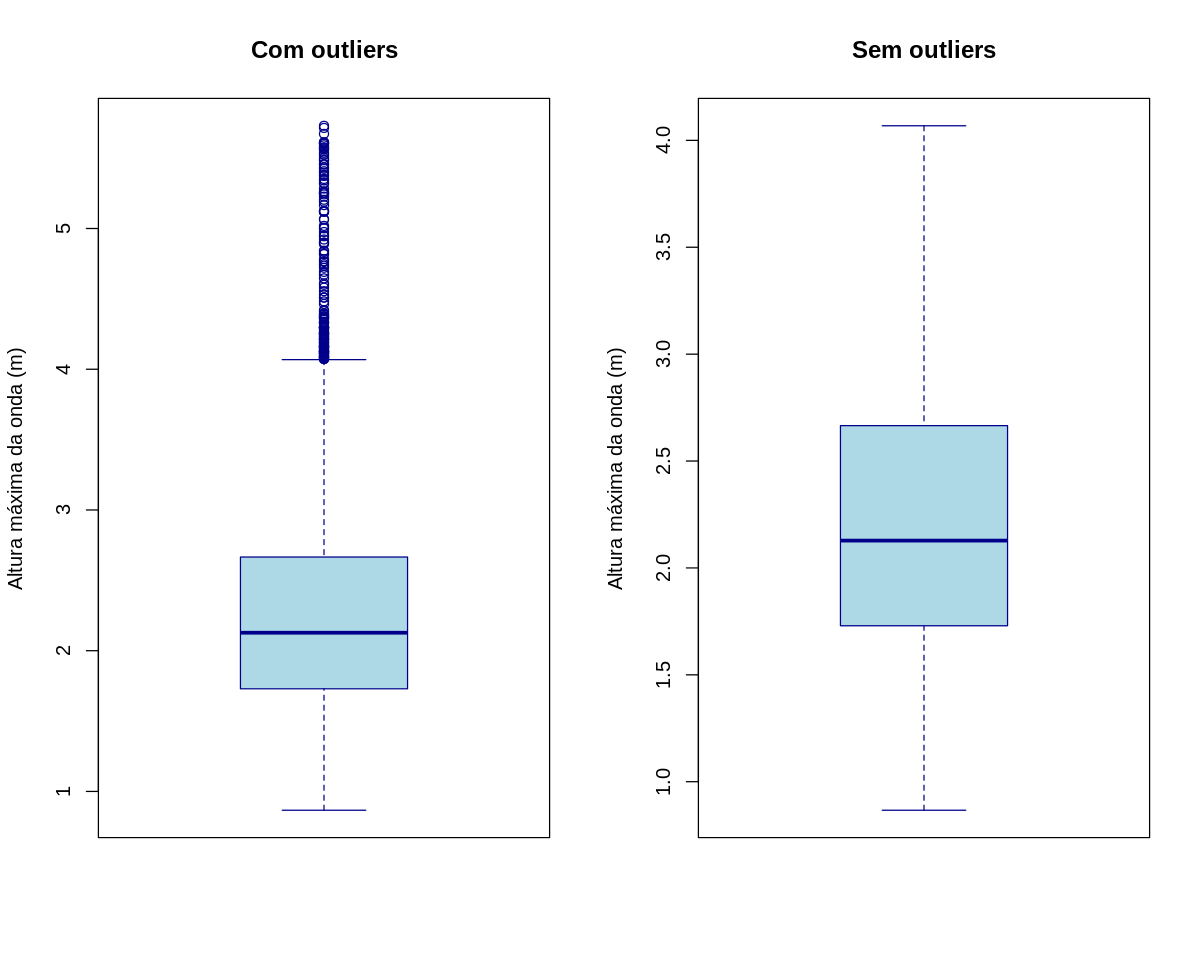

In [28]:
# Define o tamanho da figura e organiza dois gráficos lado a lado
options(repr.plot.width = 10, repr.plot.height = 8)
par(mfrow = c(1, 2))

# Boxplot 1: com outliers — mostra toda a distribuição incluindo valores extremos
boxplot(y,
        main    = "Com outliers",
        ylab    = "Altura máxima da onda (m)",
        col     = "lightblue",
        border  = "darkblue",
        notch   = FALSE)

# Boxplot 2: sem outliers (outline=FALSE) — facilita a leitura da caixa central
# Os pontos extremos são omitidos do gráfico, mas ainda existem nos dados
boxplot(y,
        main    = "Sem outliers",
        ylab    = "Altura máxima da onda (m)",
        col     = "lightblue",
        border  = "darkblue",
        notch   = FALSE,
        outline = FALSE)

# **HISTOGRAMA DA VARIÁVEL-ALVO — COMPARAÇÃO DE REGRAS**

 Cada regra usa uma fórmula diferente para sugerir o número ideal de intervalos:

   Sturges : k = ceil(log2(n)) + 1
             Assume normalidade. Cresce muito lentamente com n, tendendo a
             subestimar o número de bins em amostras grandes (n > 200).

   Scott   : h = 3.49 * sd * n^(-1/3)
             Minimiza o erro quadrático médio integrado do estimador de densidade.
             Sensível a outliers por depender do desvio padrão.

   FD      : h = 2 * IQR * n^(-1/3)
             Versão robusta de Scott: substitui o sd pelo IQR.
            Recomendada para distribuições assimétricas ou com outliers.

In [29]:
# Imprime o número de intervalos sugerido por cada regra
nclass.Sturges(y)
nclass.scott(y)
nclass.FD(y)

[1] 15

[1] 38

[1] 54

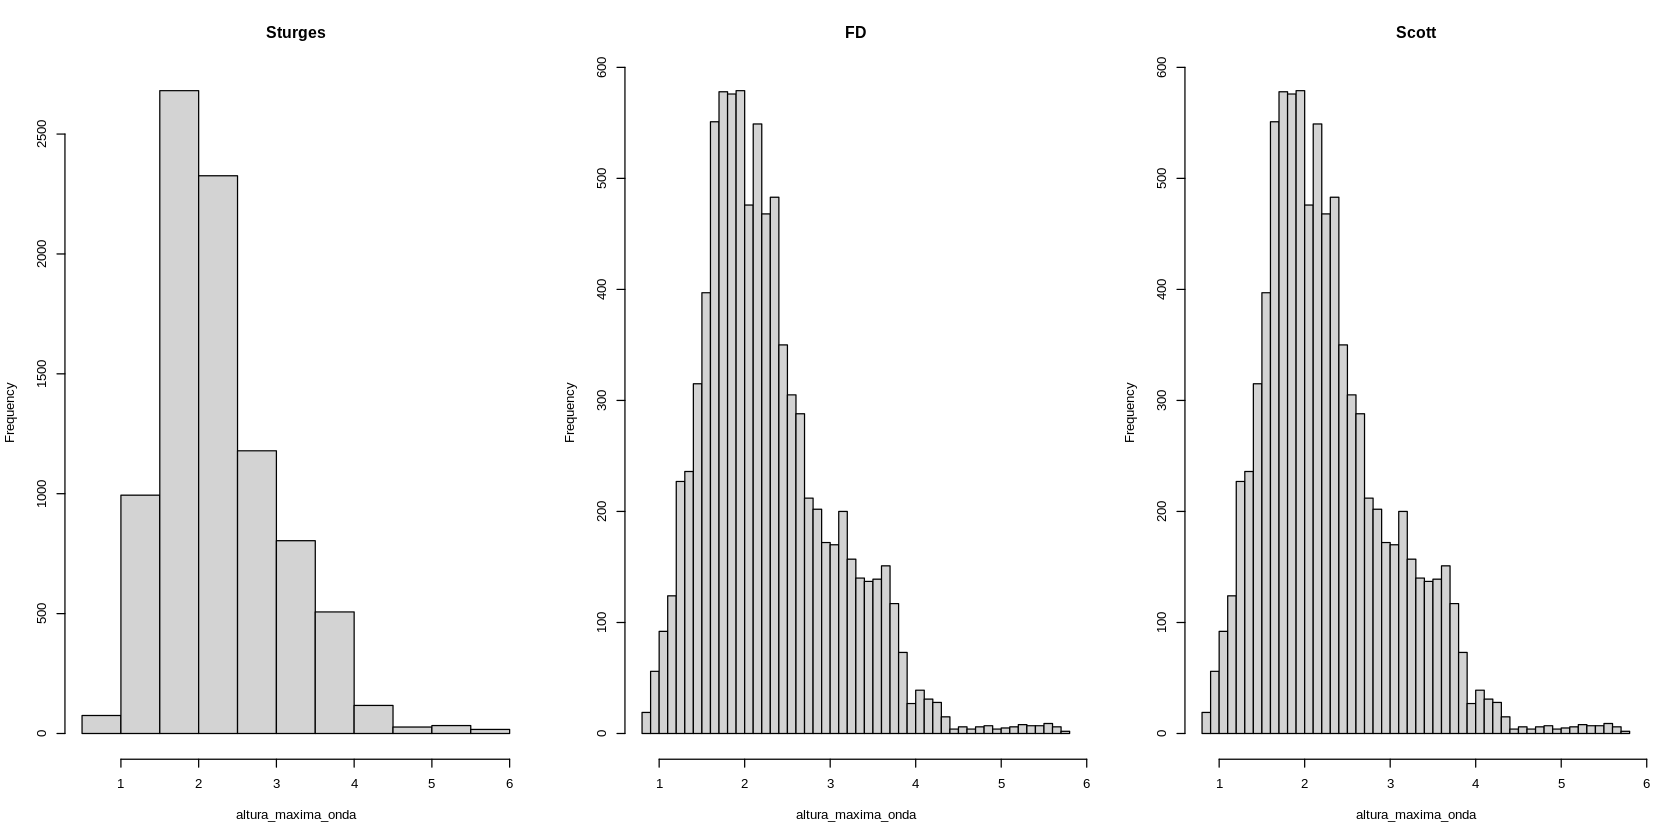

In [30]:
# Plota os três histogramas lado a lado para comparação visual
options(repr.plot.width = 14, repr.plot.height = 7)
par(mfrow = c(1, 3))
hist(y, breaks = nclass.Sturges(y), main = "Sturges", xlab = "altura_maxima_onda")
hist(y, breaks = nclass.FD(y),      main = "FD",      xlab = "altura_maxima_onda")
hist(y, breaks = nclass.scott(y),   main = "Scott",   xlab = "altura_maxima_onda")

# **VERIFICANDO A DISTRIBUIÇÃO DE TODAS AS VARIÁVEIS NUMÉRICAS**

In [31]:
# Obtém os nomes de todas as colunas numéricas do dataframe
# sapply() aplica is.numeric() a cada coluna e retorna um vetor TRUE/FALSE
# names()[...] filtra apenas os nomes onde o resultado foi TRUE
vars_numericas <- names(df)[sapply(df, is.numeric)]

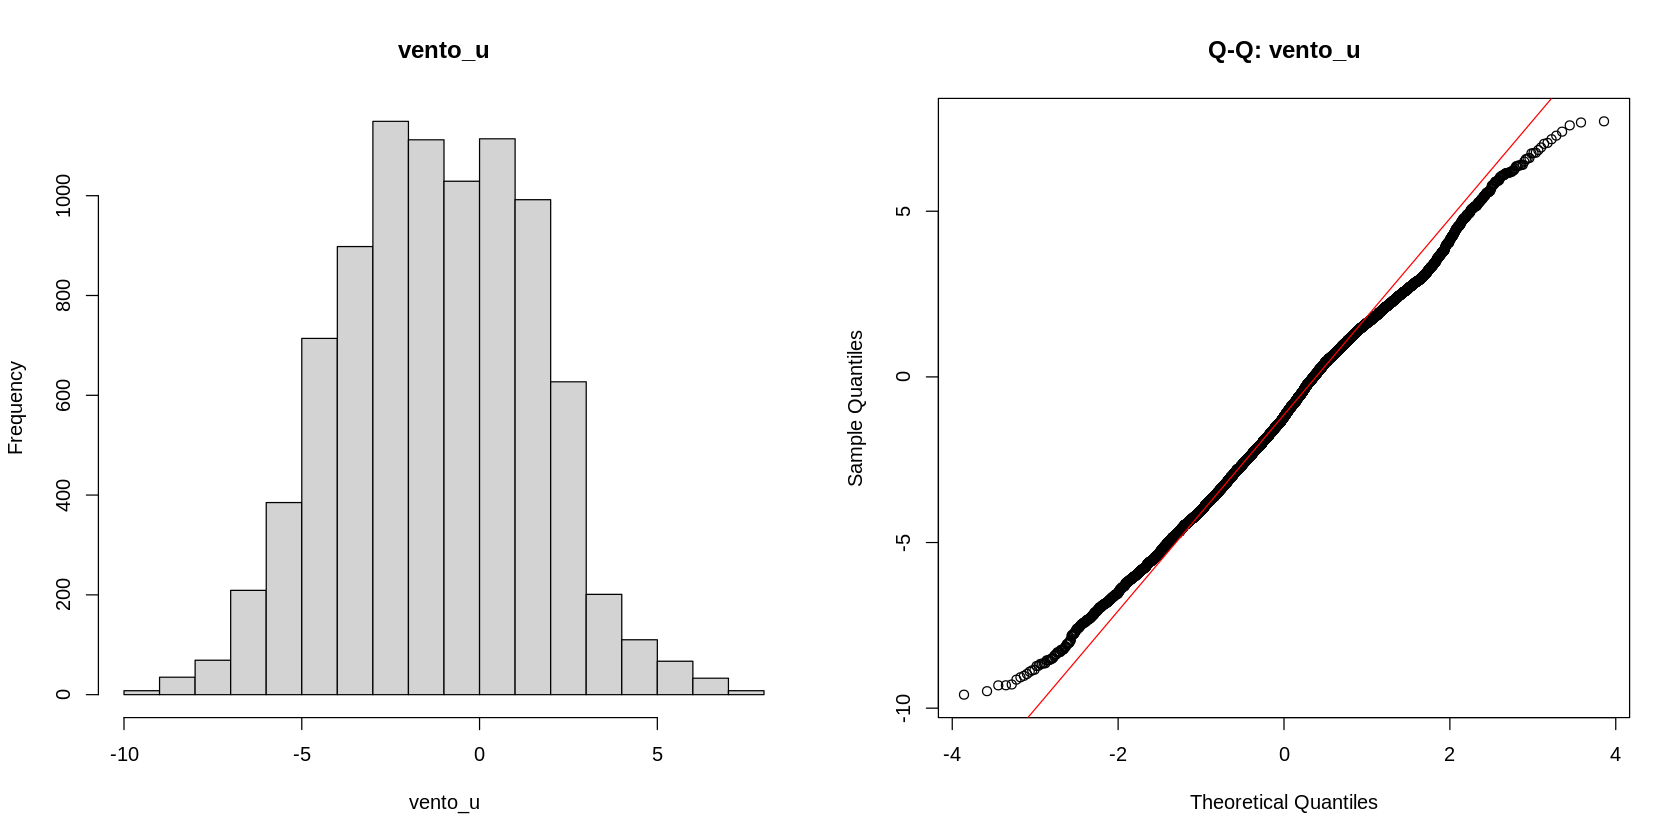

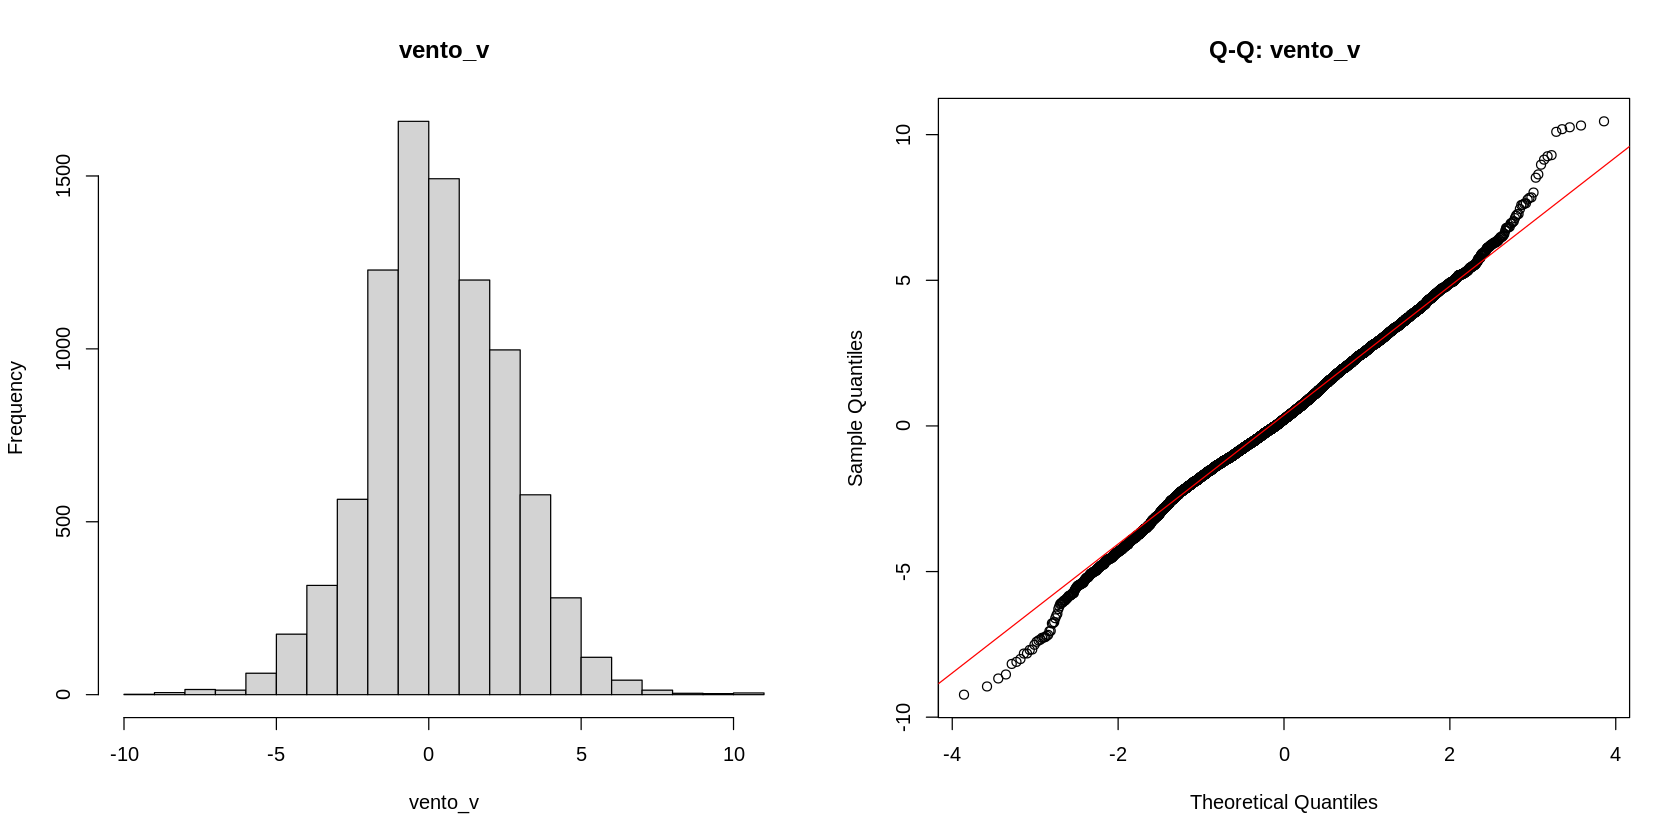

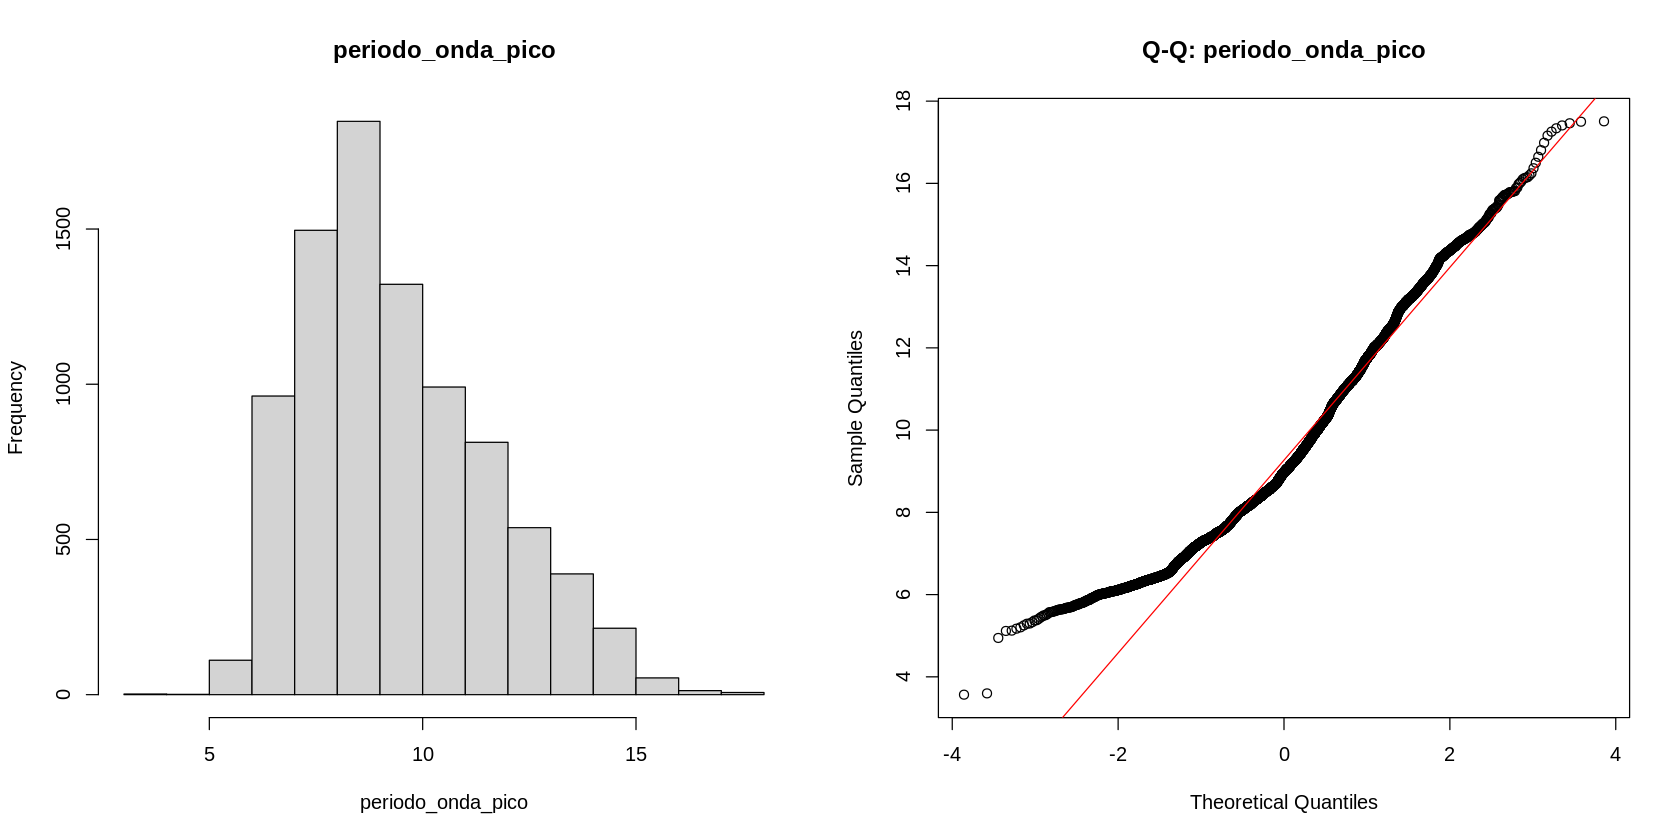

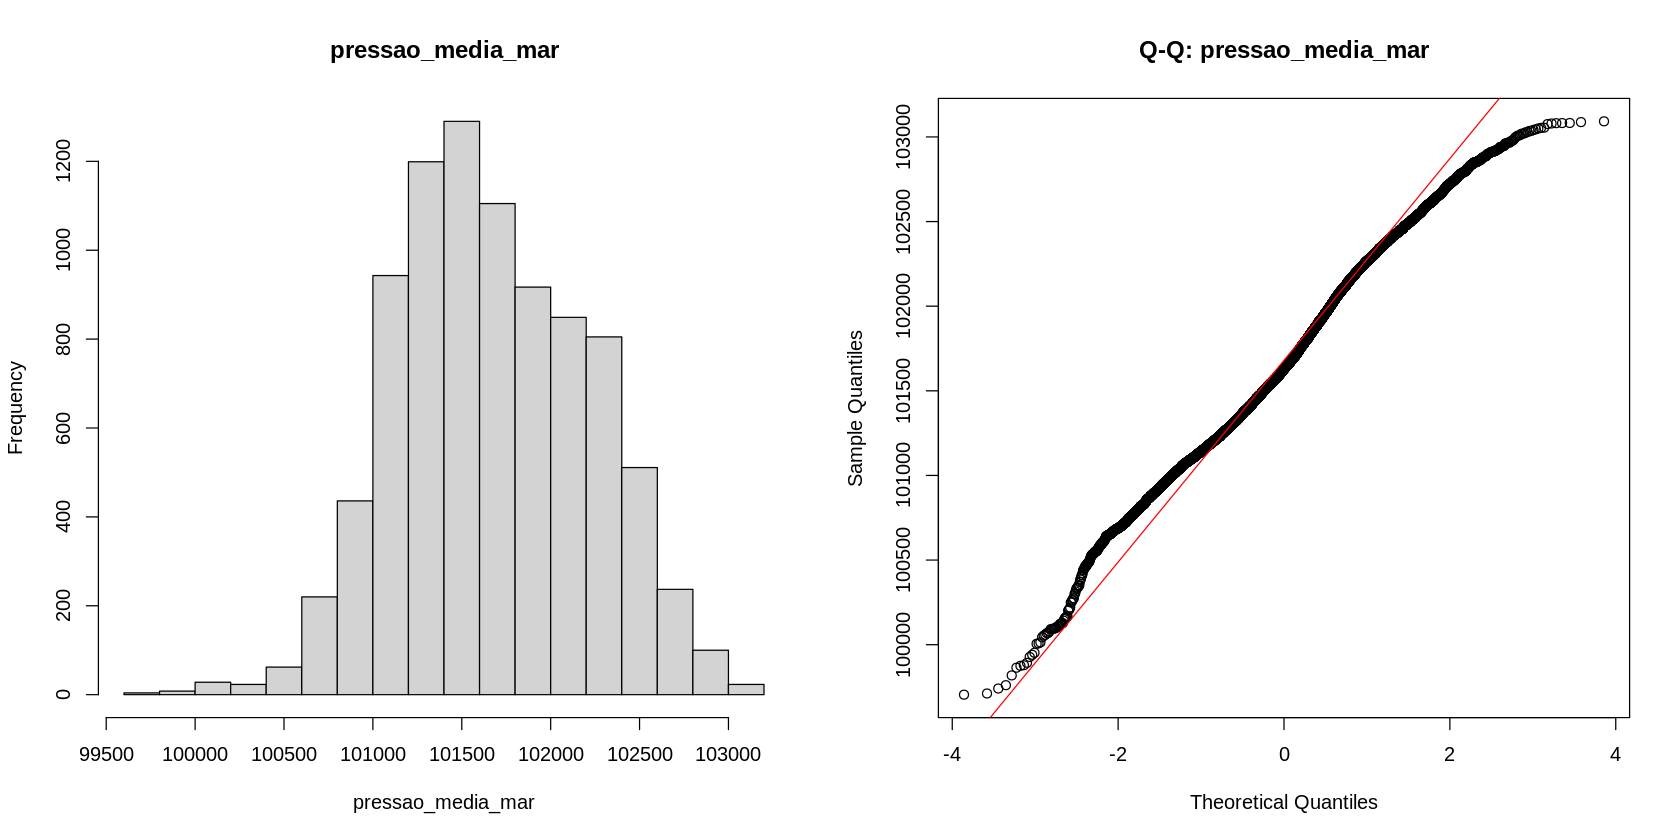

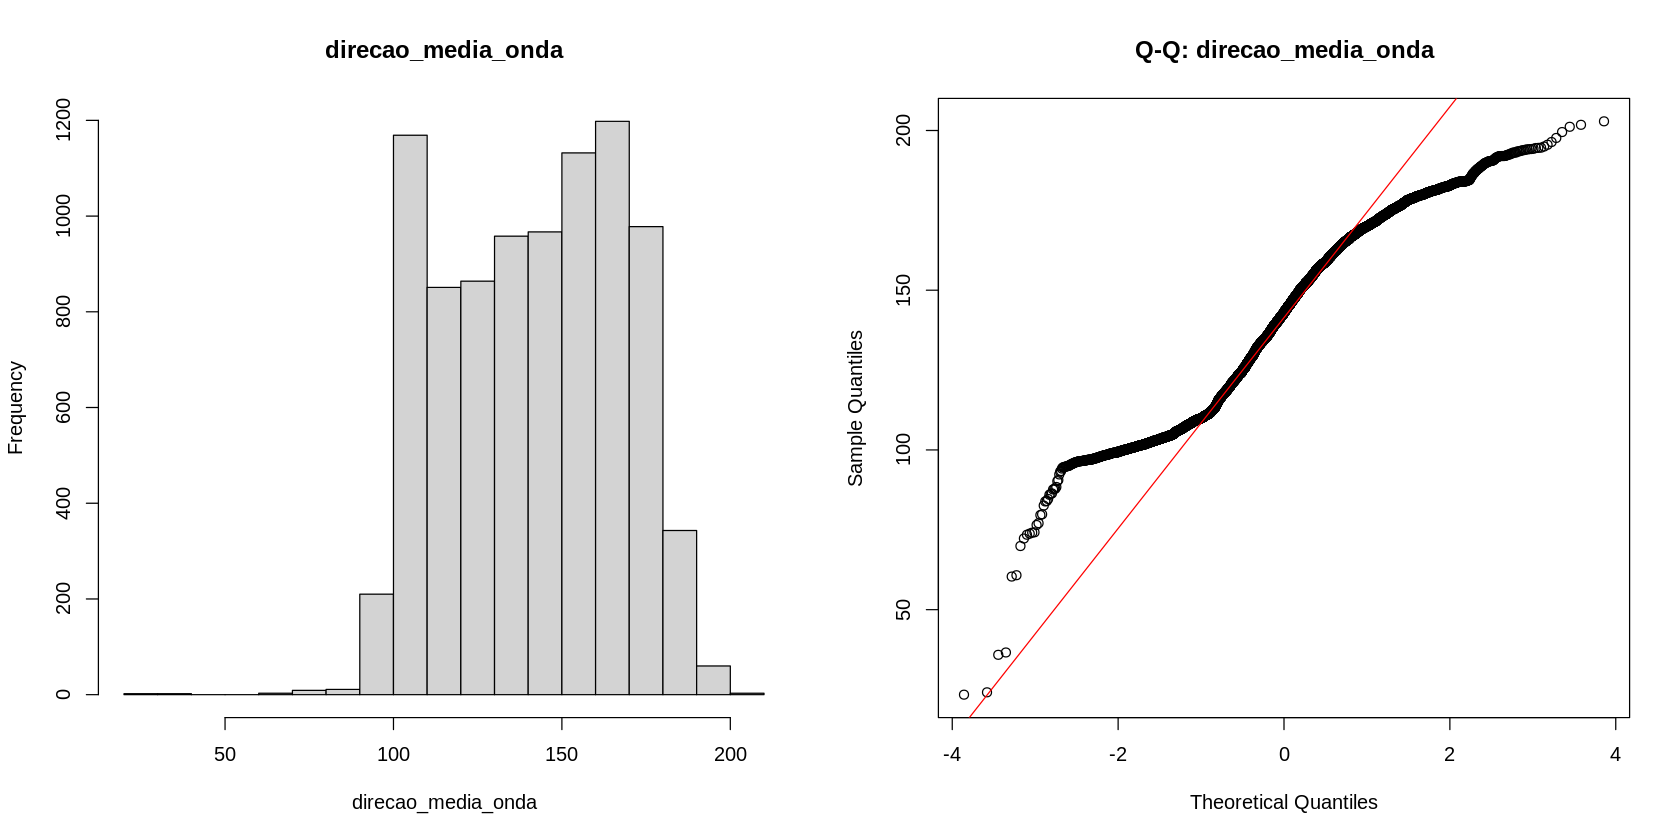

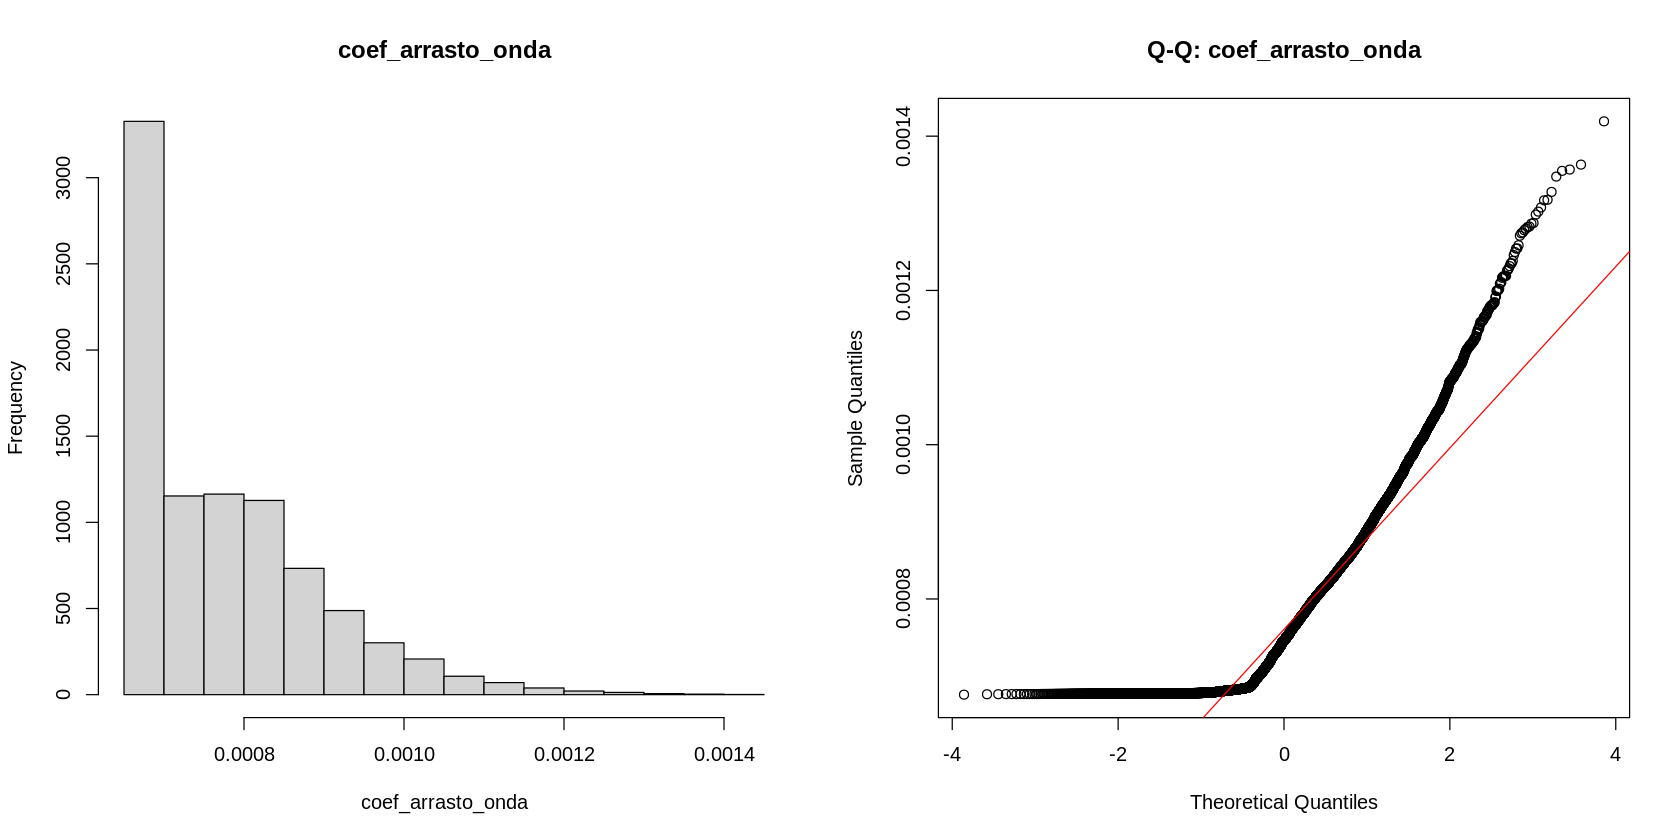

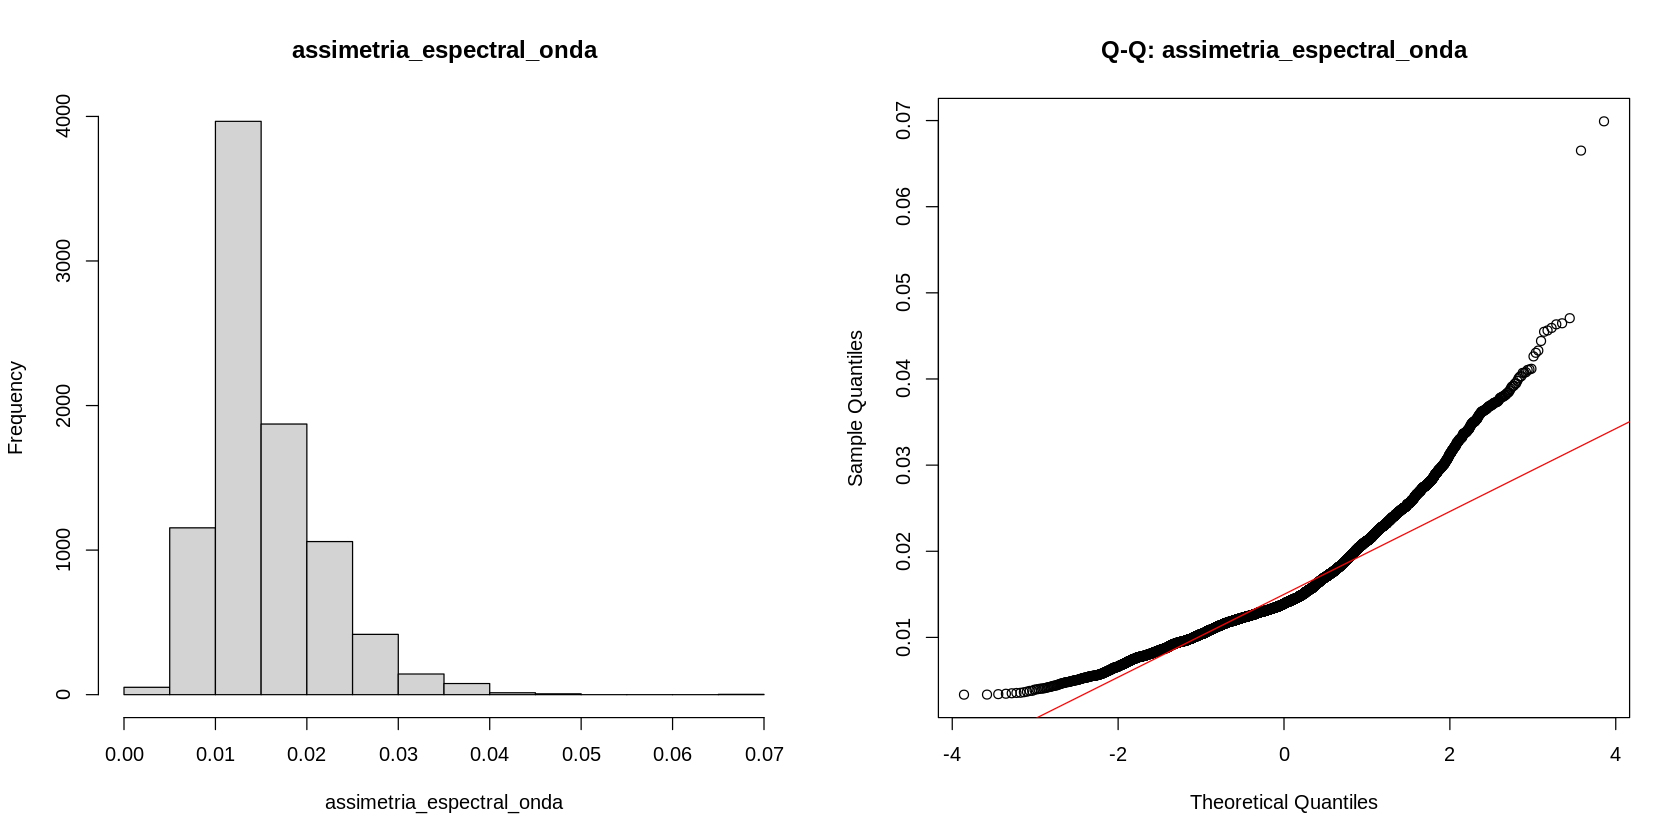

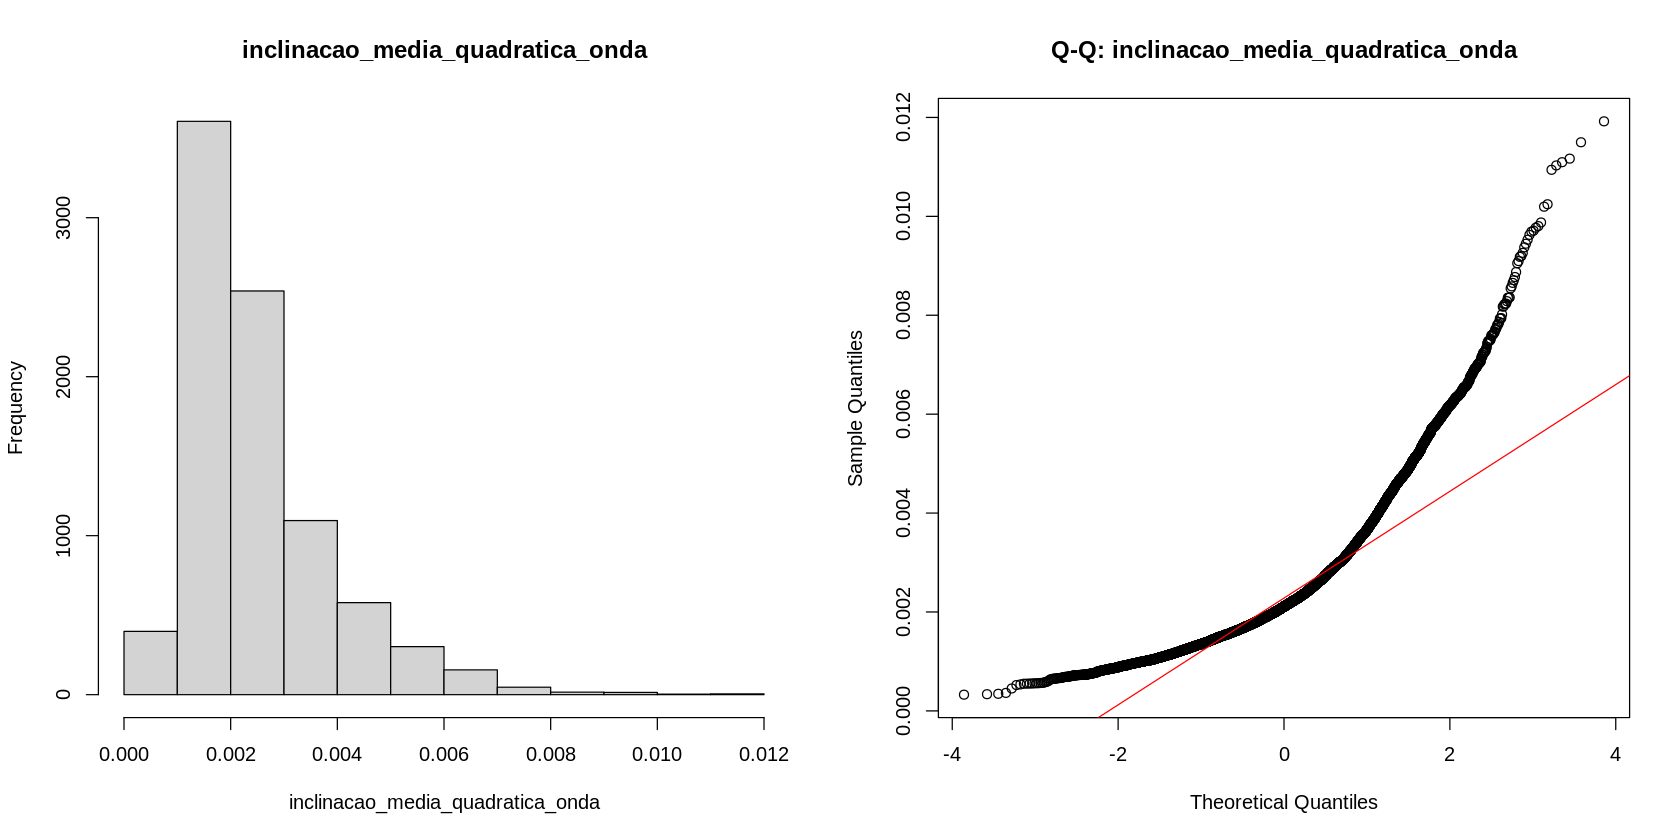

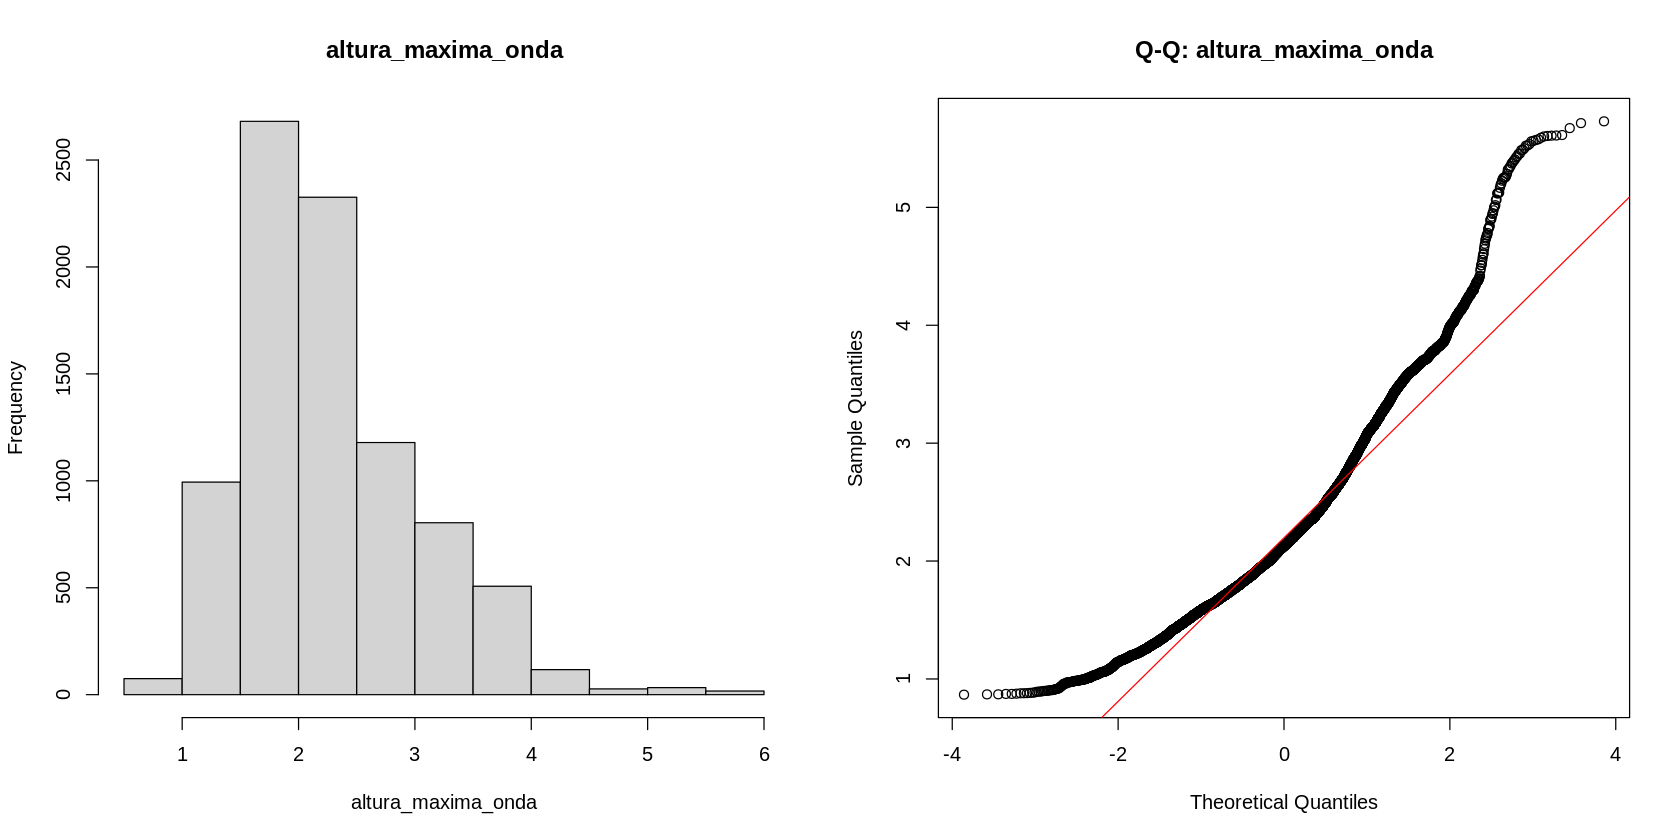

In [32]:
# Para cada variável numérica, gera um par de gráficos (histograma + Q-Q plot)
# lado a lado para avaliação visual da normalidade
par(mfrow = c(1, 2))

for (var in vars_numericas) {
  # Histograma da variável
  hist(df[[var]], main = var, xlab = var)

  # Q-Q plot: compara os quantis dos dados com os quantis de uma normal teórica
  # Quanto mais os pontos seguirem a linha vermelha, mais normal é a distribuição
  qqnorm(df[[var]], main = paste("Q-Q:", var))
  qqline(df[[var]], col = "red")
}

par(mfrow = c(1, 1)) # Reseta o layout de múltiplos painéis

# **VERIFICANDO OUTLIERS DE TODAS AS VARIÁVEIS NUMÉRICAS**

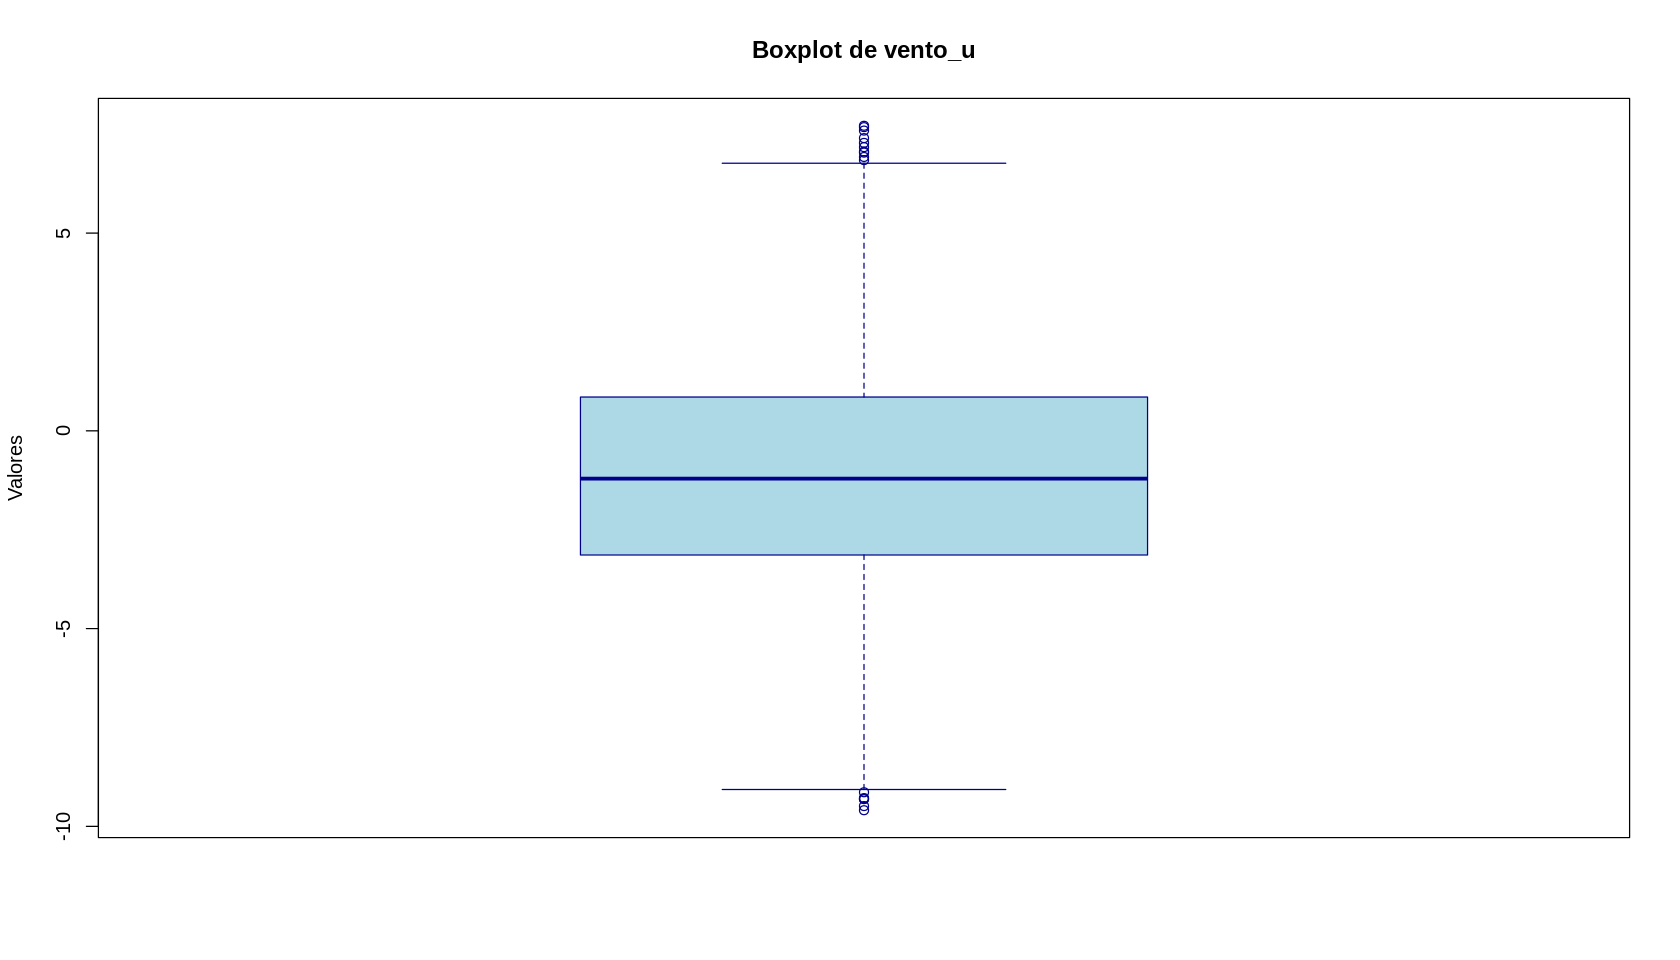

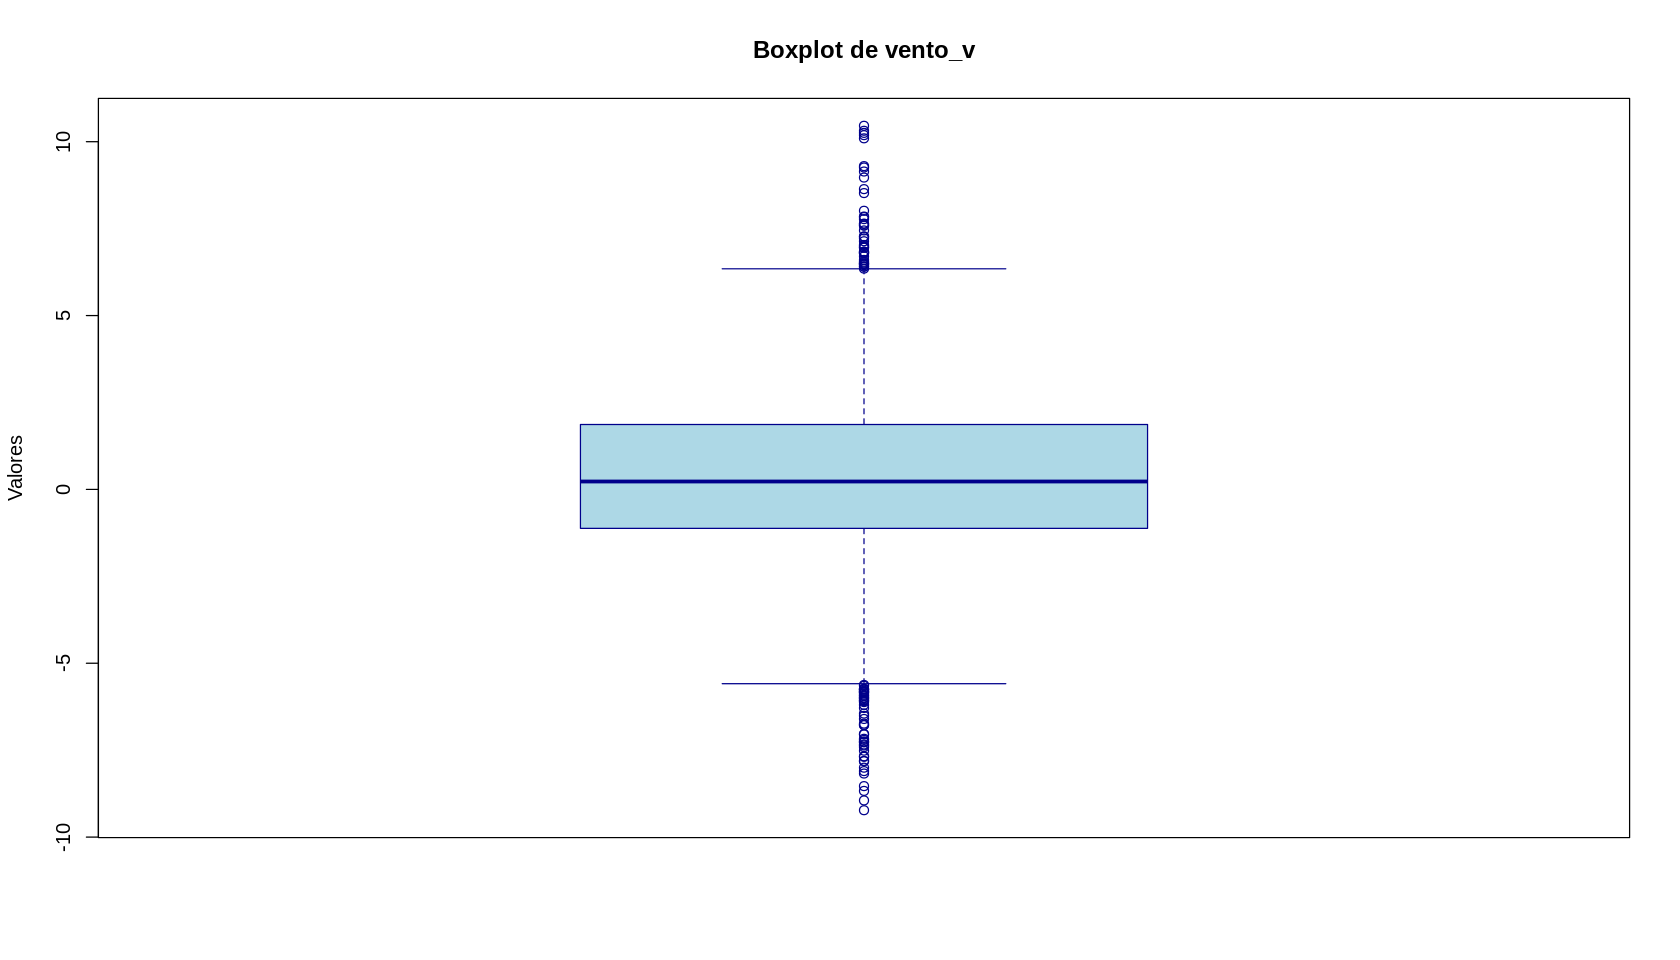

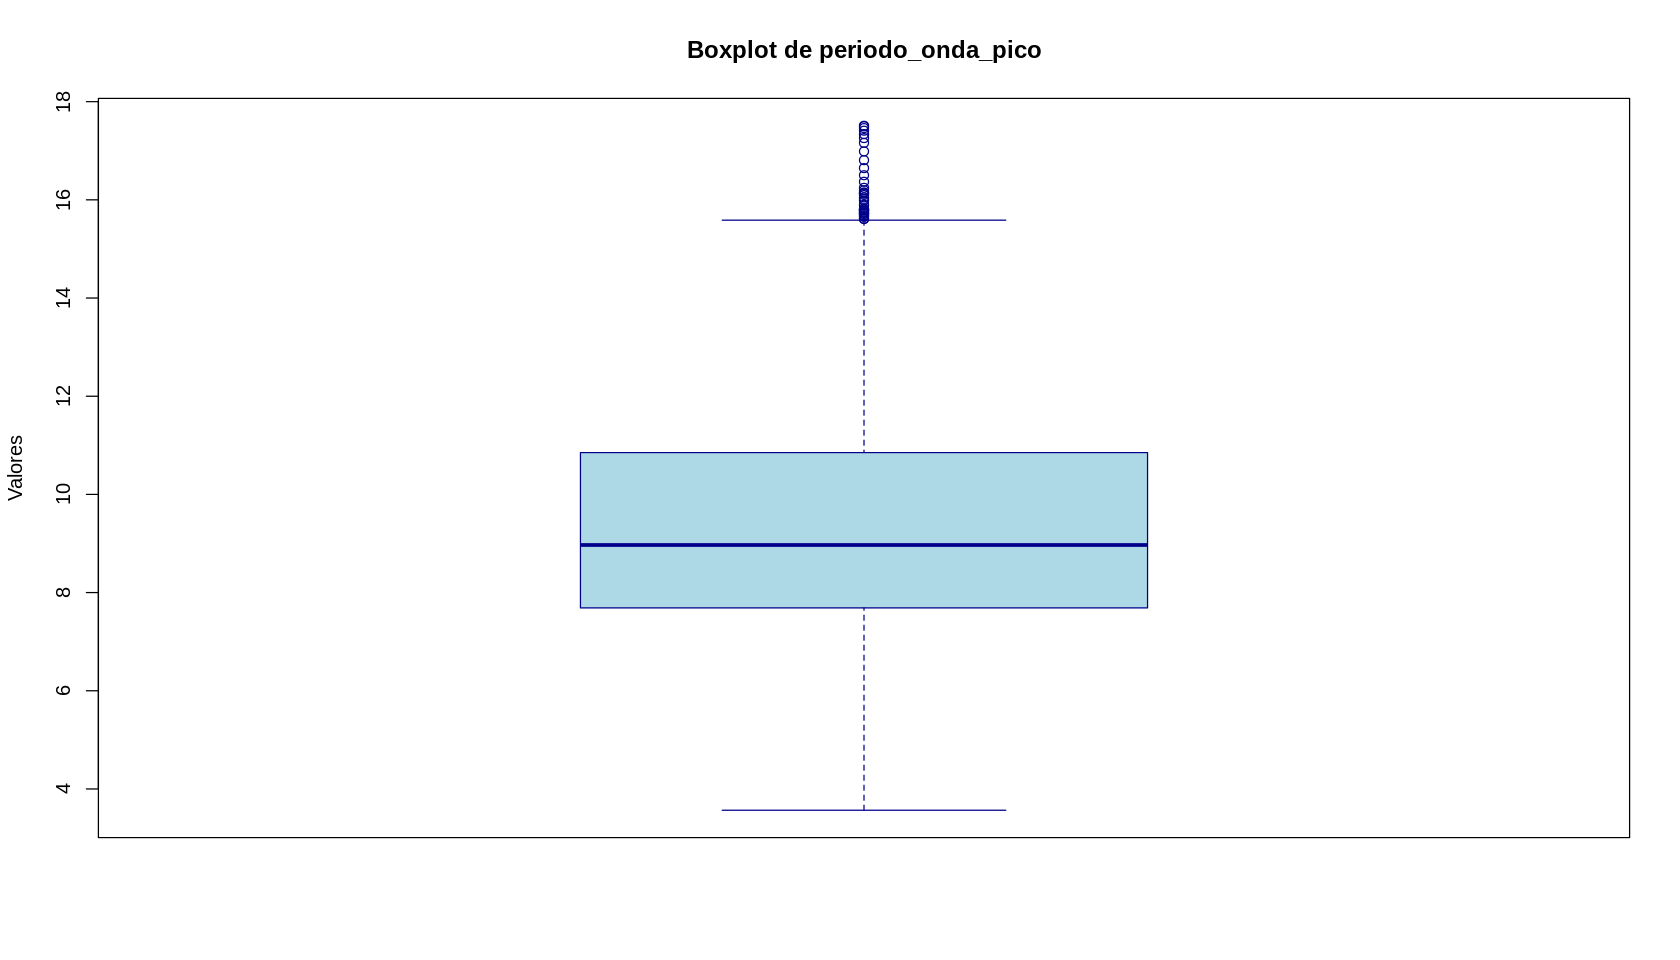

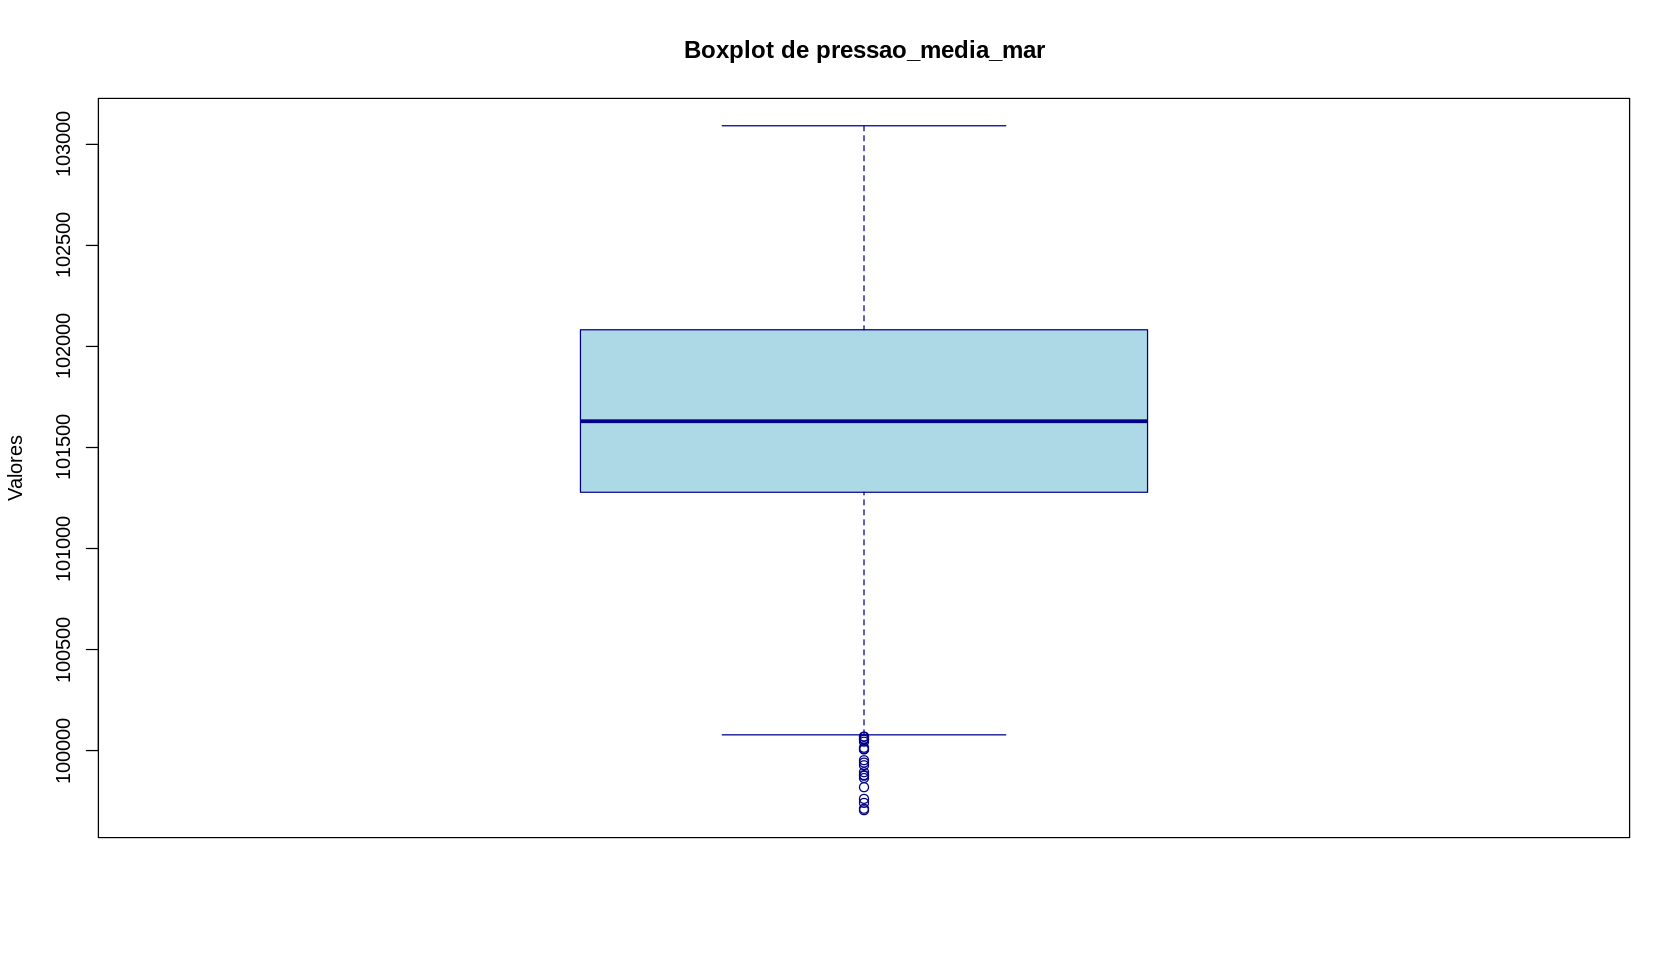

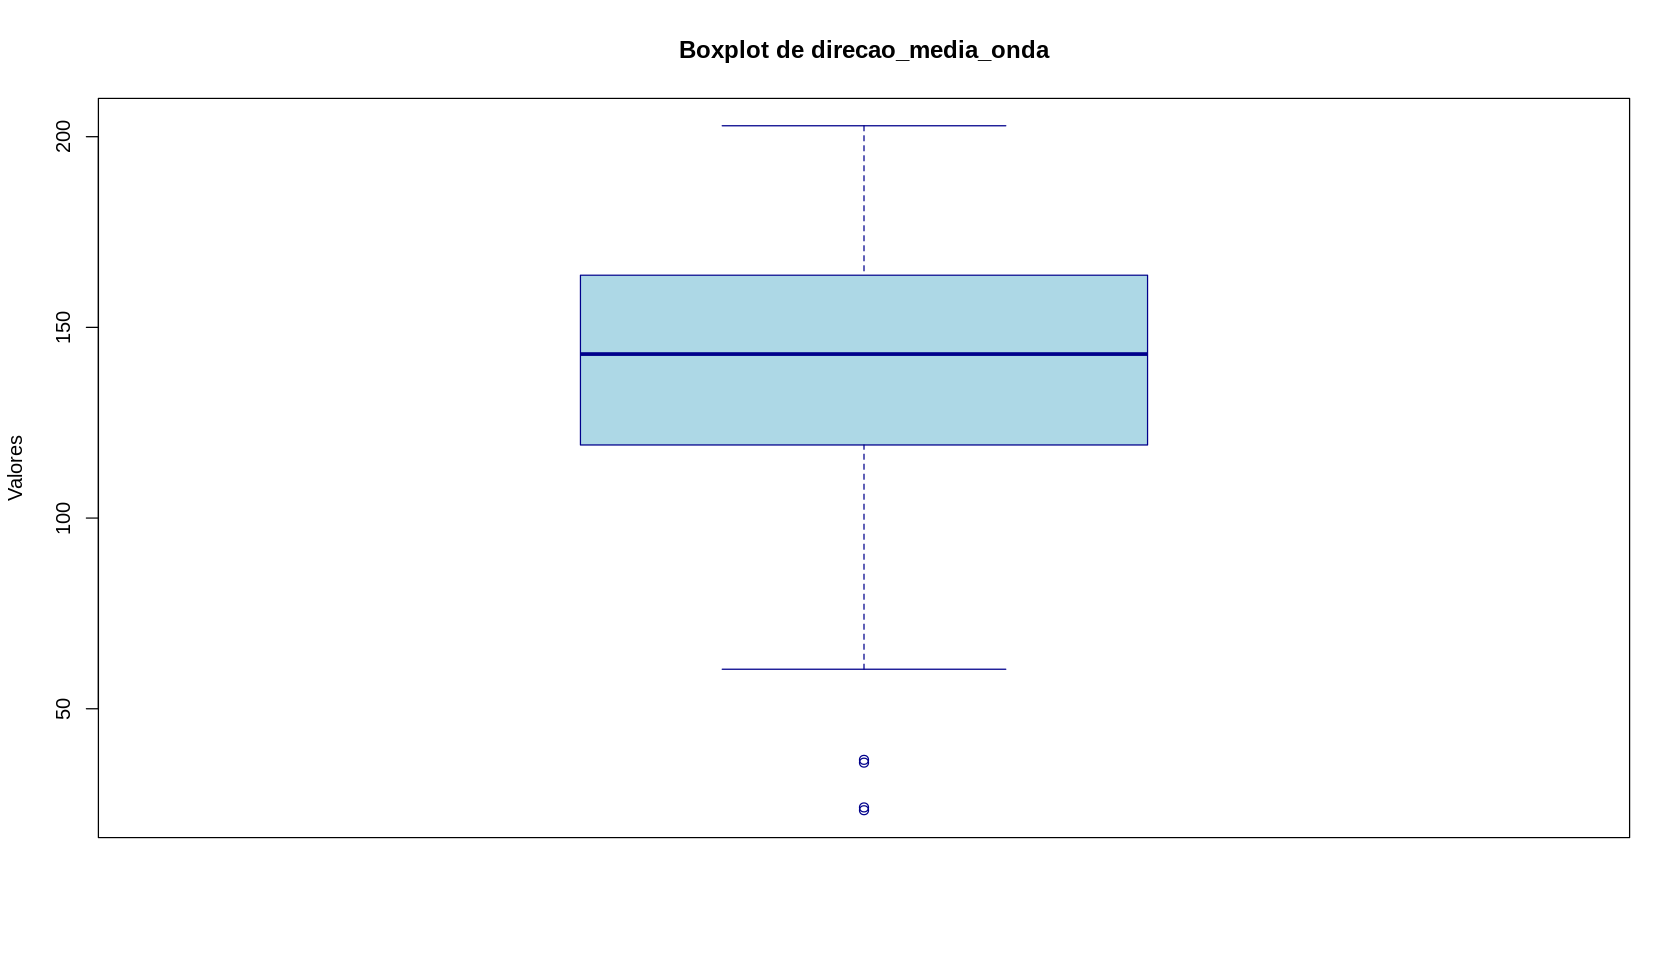

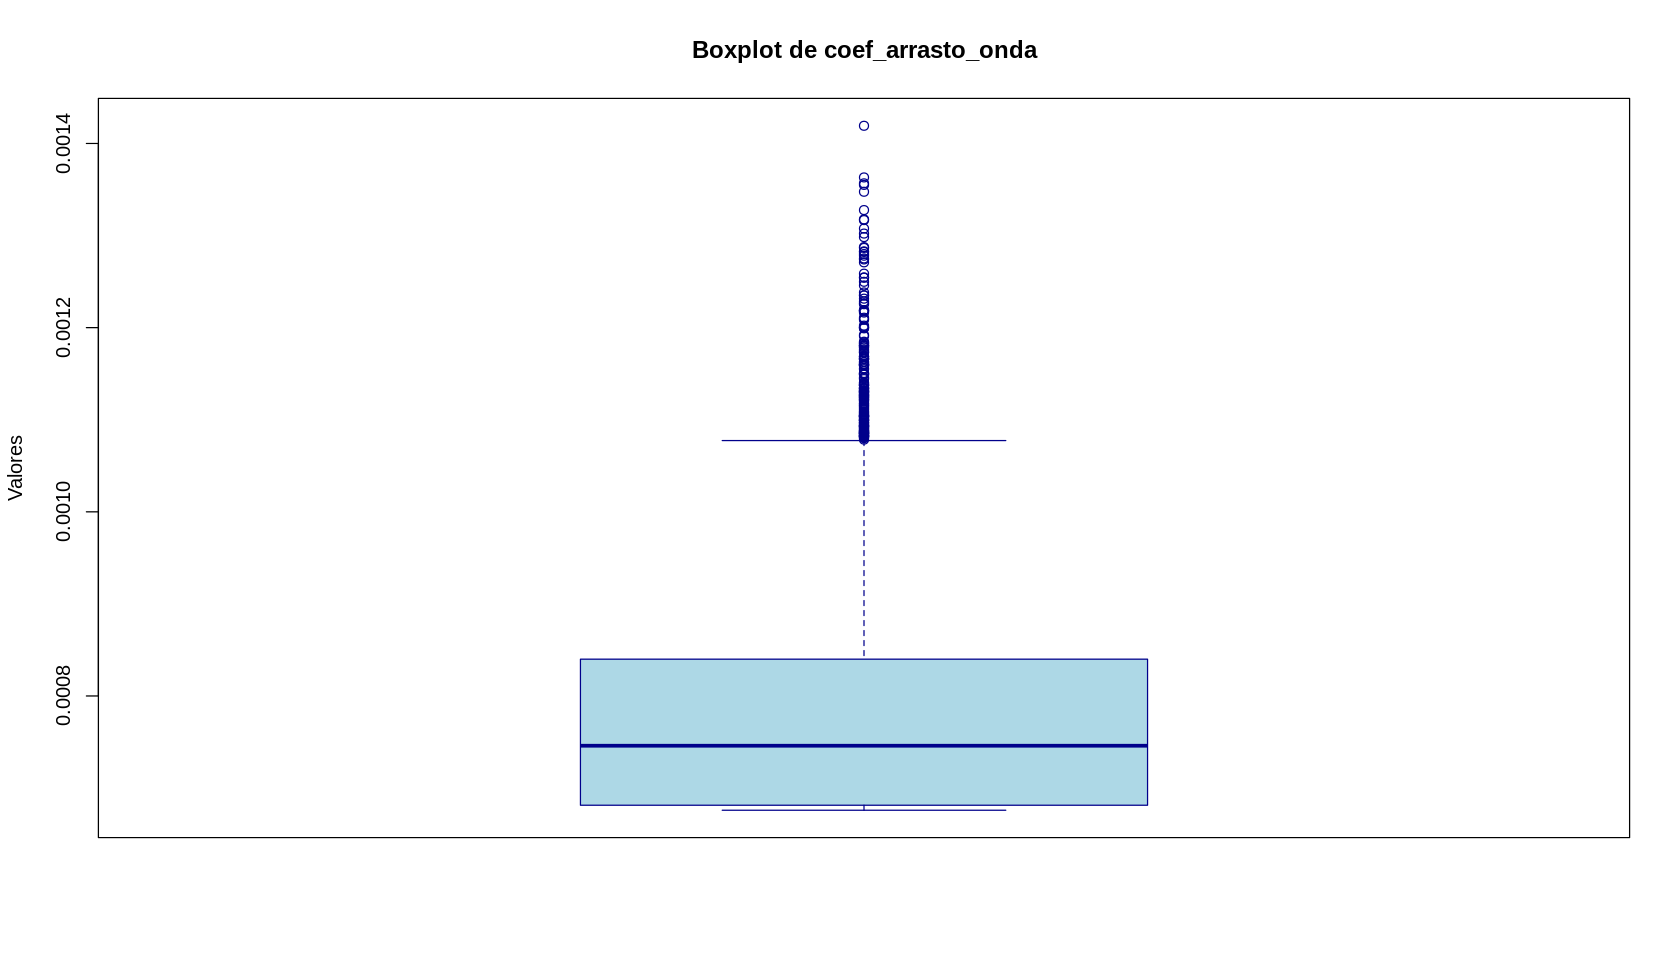

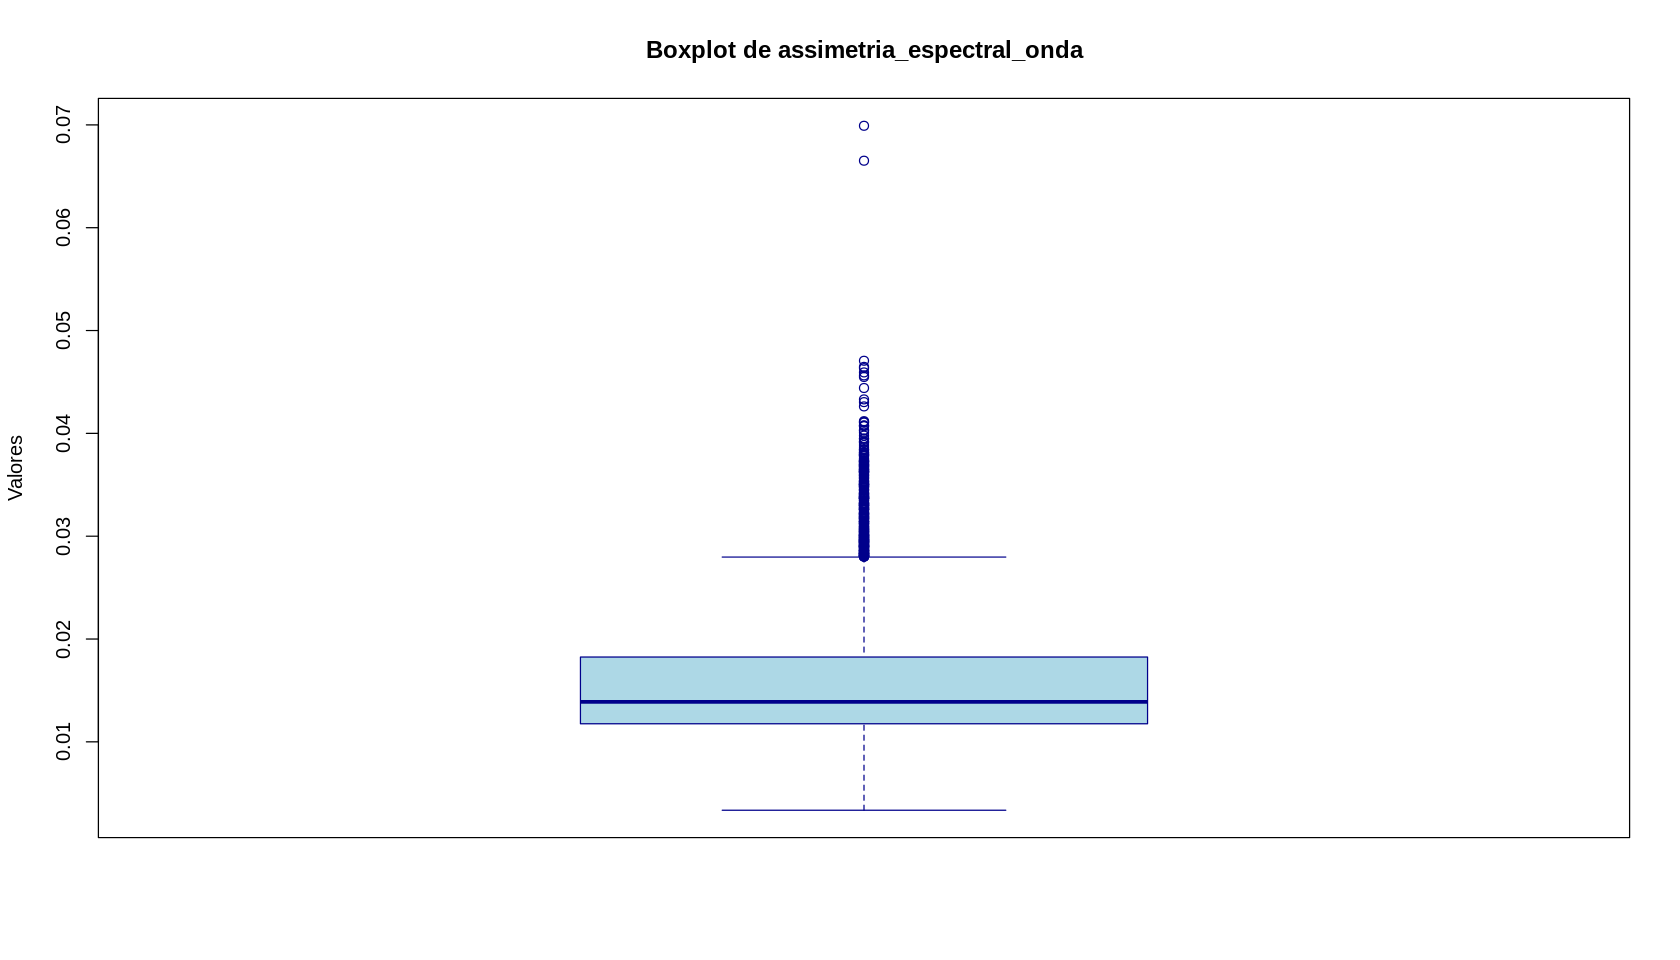

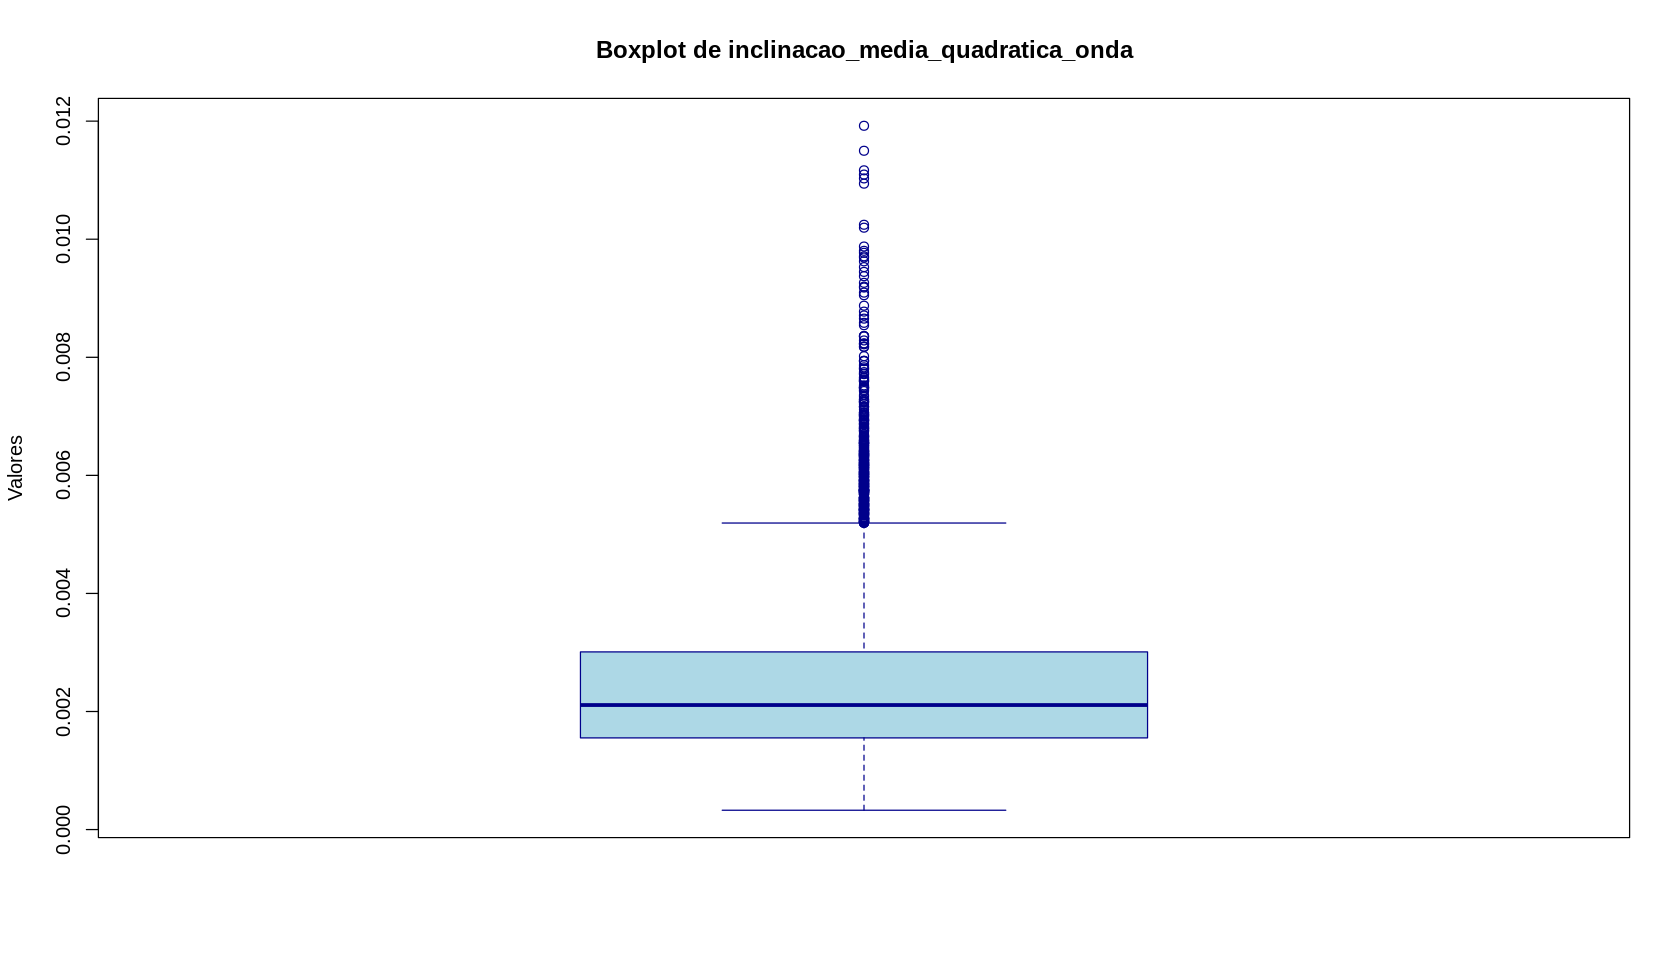

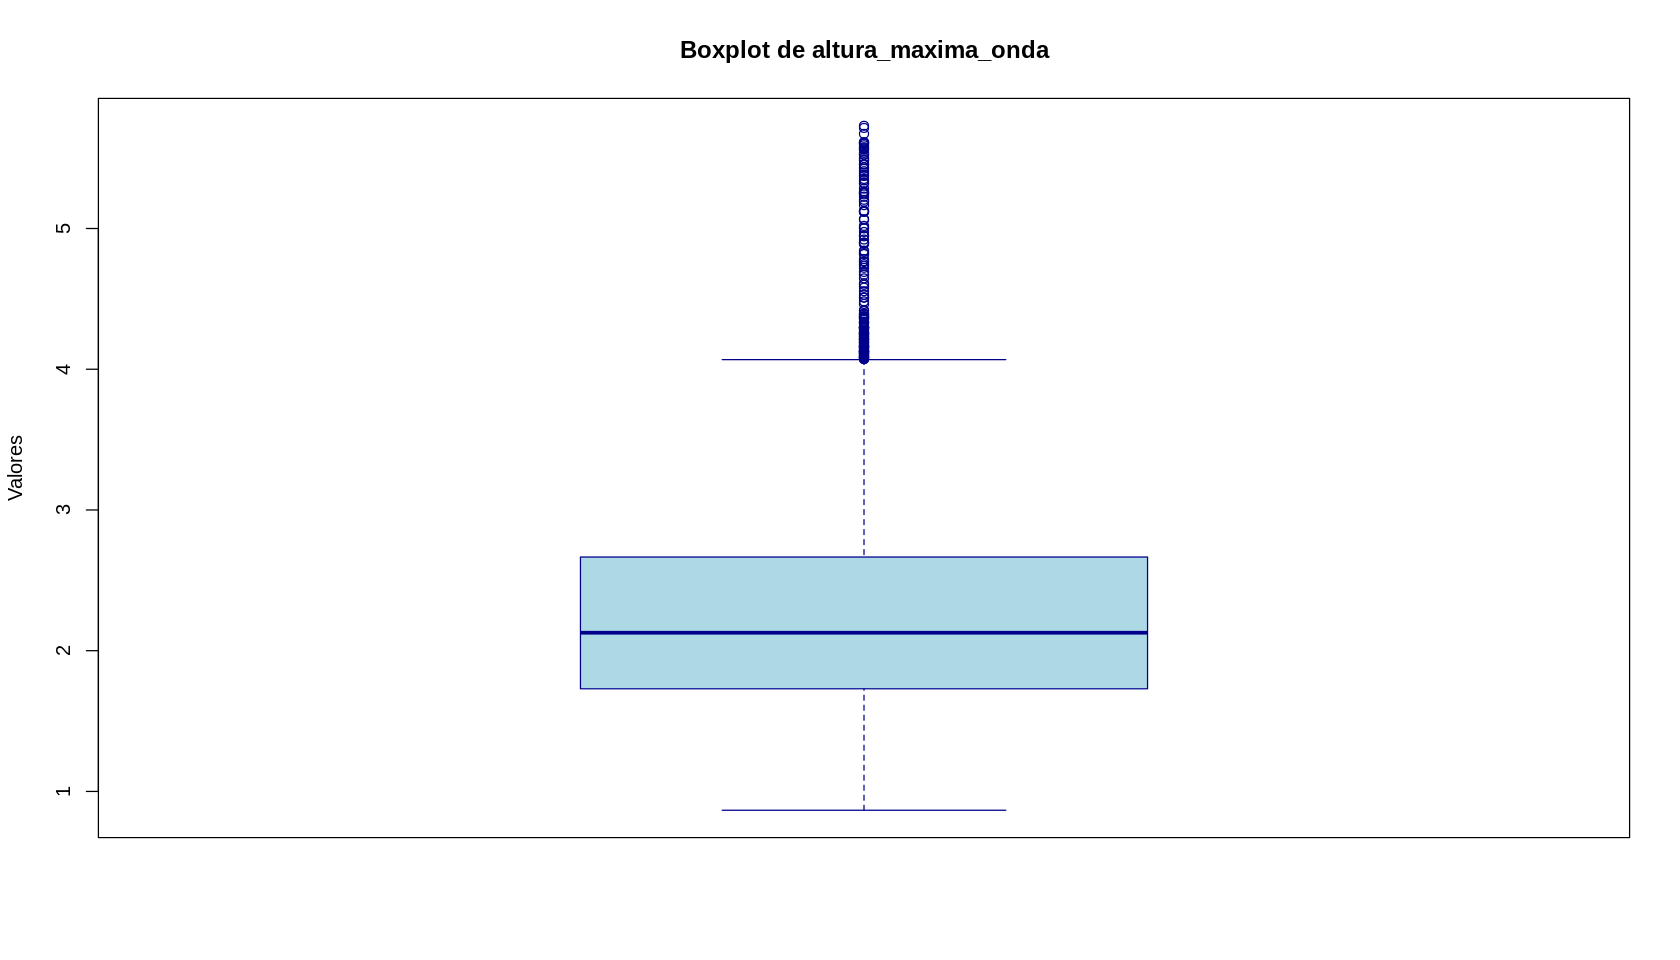

In [33]:
options(repr.plot.width = 14, repr.plot.height = 8)

# Gera um boxplot individual para cada variável numérica
# Permite identificar visualmente a presença e magnitude dos outliers em cada uma
for (var in vars_numericas) {
  boxplot(df[[var]],
          main   = paste("Boxplot de", var),
          ylab   = "Valores",
          col    = "lightblue",
          border = "darkblue",
          notch  = FALSE)
}

# **CRIANDO VARIÁVEIS QUALITATIVAS ORDINAIS POR INTERVALOS**

Variáveis que apresentaram distribuição aproximadamente normal no Q-Q plot
(seção 6) e outliers leves/simétricos → método Scott é adequado.
As demais variáveis usarão FD, mais robusto a assimetria e outliers.

In [34]:
vars_scott <- c("vento_u", "vento_v", "pressao_media_mar")

In [35]:
# ─── Função auxiliar: calcula os breakpoints (pontos de corte) ───────────────
# Recebe: x      = vetor numérico da variável
#         metodo = "Scott" ou "FD"
# Retorna: sequência de n+1 valores igualmente espaçados entre min e max,
#          onde n é o número de intervalos sugerido pelo método escolhido.
calc_breaks <- function(x, metodo) {

  # Remove NAs antes de calcular — nclass.scott() e nclass.FD() falham com NA
  x_limpo <- x[!is.na(x)]

  # switch() funciona como um if/else encadeado baseado no valor de 'metodo'
  n <- switch(metodo,
    "Scott" = nclass.scott(x_limpo), # n baseado no desvio padrão
    "FD"    = nclass.FD(x_limpo)     # n baseado no IQR
  )

  # Gera n+1 pontos de corte igualmente espaçados entre min e max
  # São n+1 pontos porque n intervalos precisam de n+1 divisórias
  # Em R, a última expressão de uma função é automaticamente o valor retornado
  seq(min(x_limpo), max(x_limpo), length.out = n + 1)
}

In [36]:
# ─── Loop principal: cria a variável qualitativa para cada variável numérica ──
for (var in vars_numericas) {

  # Seleciona o método conforme a distribuição da variável
  # %in% é o operador de pertencimento do R (equivalente ao 'in' do Python)
  met  <- if (var %in% vars_scott) "Scott" else "FD"

  # Calcula os breakpoints usando o método selecionado
  brks <- calc_breaks(df[[var]], met)

  # Cria a nova coluna qualitativa com o nome "variavel_Metodo" (ex: vento_u_Scott)
  # cut() transforma o vetor numérico em fator categórico ordenado
  df[[paste0(var, "_", met)]] <- cut(
    df[[var]],
    breaks         = brks,  # pontos de corte calculados acima
    include.lowest = TRUE,  # inclui o valor mínimo exato no primeiro intervalo
    right          = TRUE,  # intervalos fechados à direita: (a, b] — 'b' pertence ao intervalo
    ordered_result = TRUE   # fator ordenado: respeita a sequência natural dos intervalos
  )
}

In [37]:
# ─── Tabela de resumo: variável, método usado e número de classes criadas ─────
tabela <- data.frame(
  variavel = vars_numericas,
  metodo   = ifelse(vars_numericas %in% vars_scott, "Scott", "FD")
)

# sapply percorre vars_numericas e conta quantas classes cada variável recebeu
# nlevels() retorna o número de níveis (classes) de um fator
tabela$n_classes <- sapply(vars_numericas, function(v) {
  met <- if (v %in% vars_scott) "Scott" else "FD"
  nlevels(df[[paste0(v, "_", met)]])
})

print(tabela)

                          variavel metodo n_classes
1                          vento_u  Scott        38
2                          vento_v  Scott        52
3                periodo_onda_pico     FD        46
4                pressao_media_mar  Scott        38
5               direcao_media_onda     FD        42
6                coef_arrasto_onda     FD        49
7        assimetria_espectral_onda     FD       106
8 inclinacao_media_quadratica_onda     FD        83
9               altura_maxima_onda     FD        54


# **HISTOGRAMAS DAS VARIÁVEIS QUALITATIVAS**

In [38]:
install.packages("ggplot2")
install.packages("gridExtra")
library(ggplot2)
library(gridExtra)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [39]:
# Pega os nomes das colunas qualitativas criadas na seção 8
vars_quali <- names(df)[sapply(df, function(x) is.factor(x) | is.ordered(x))]

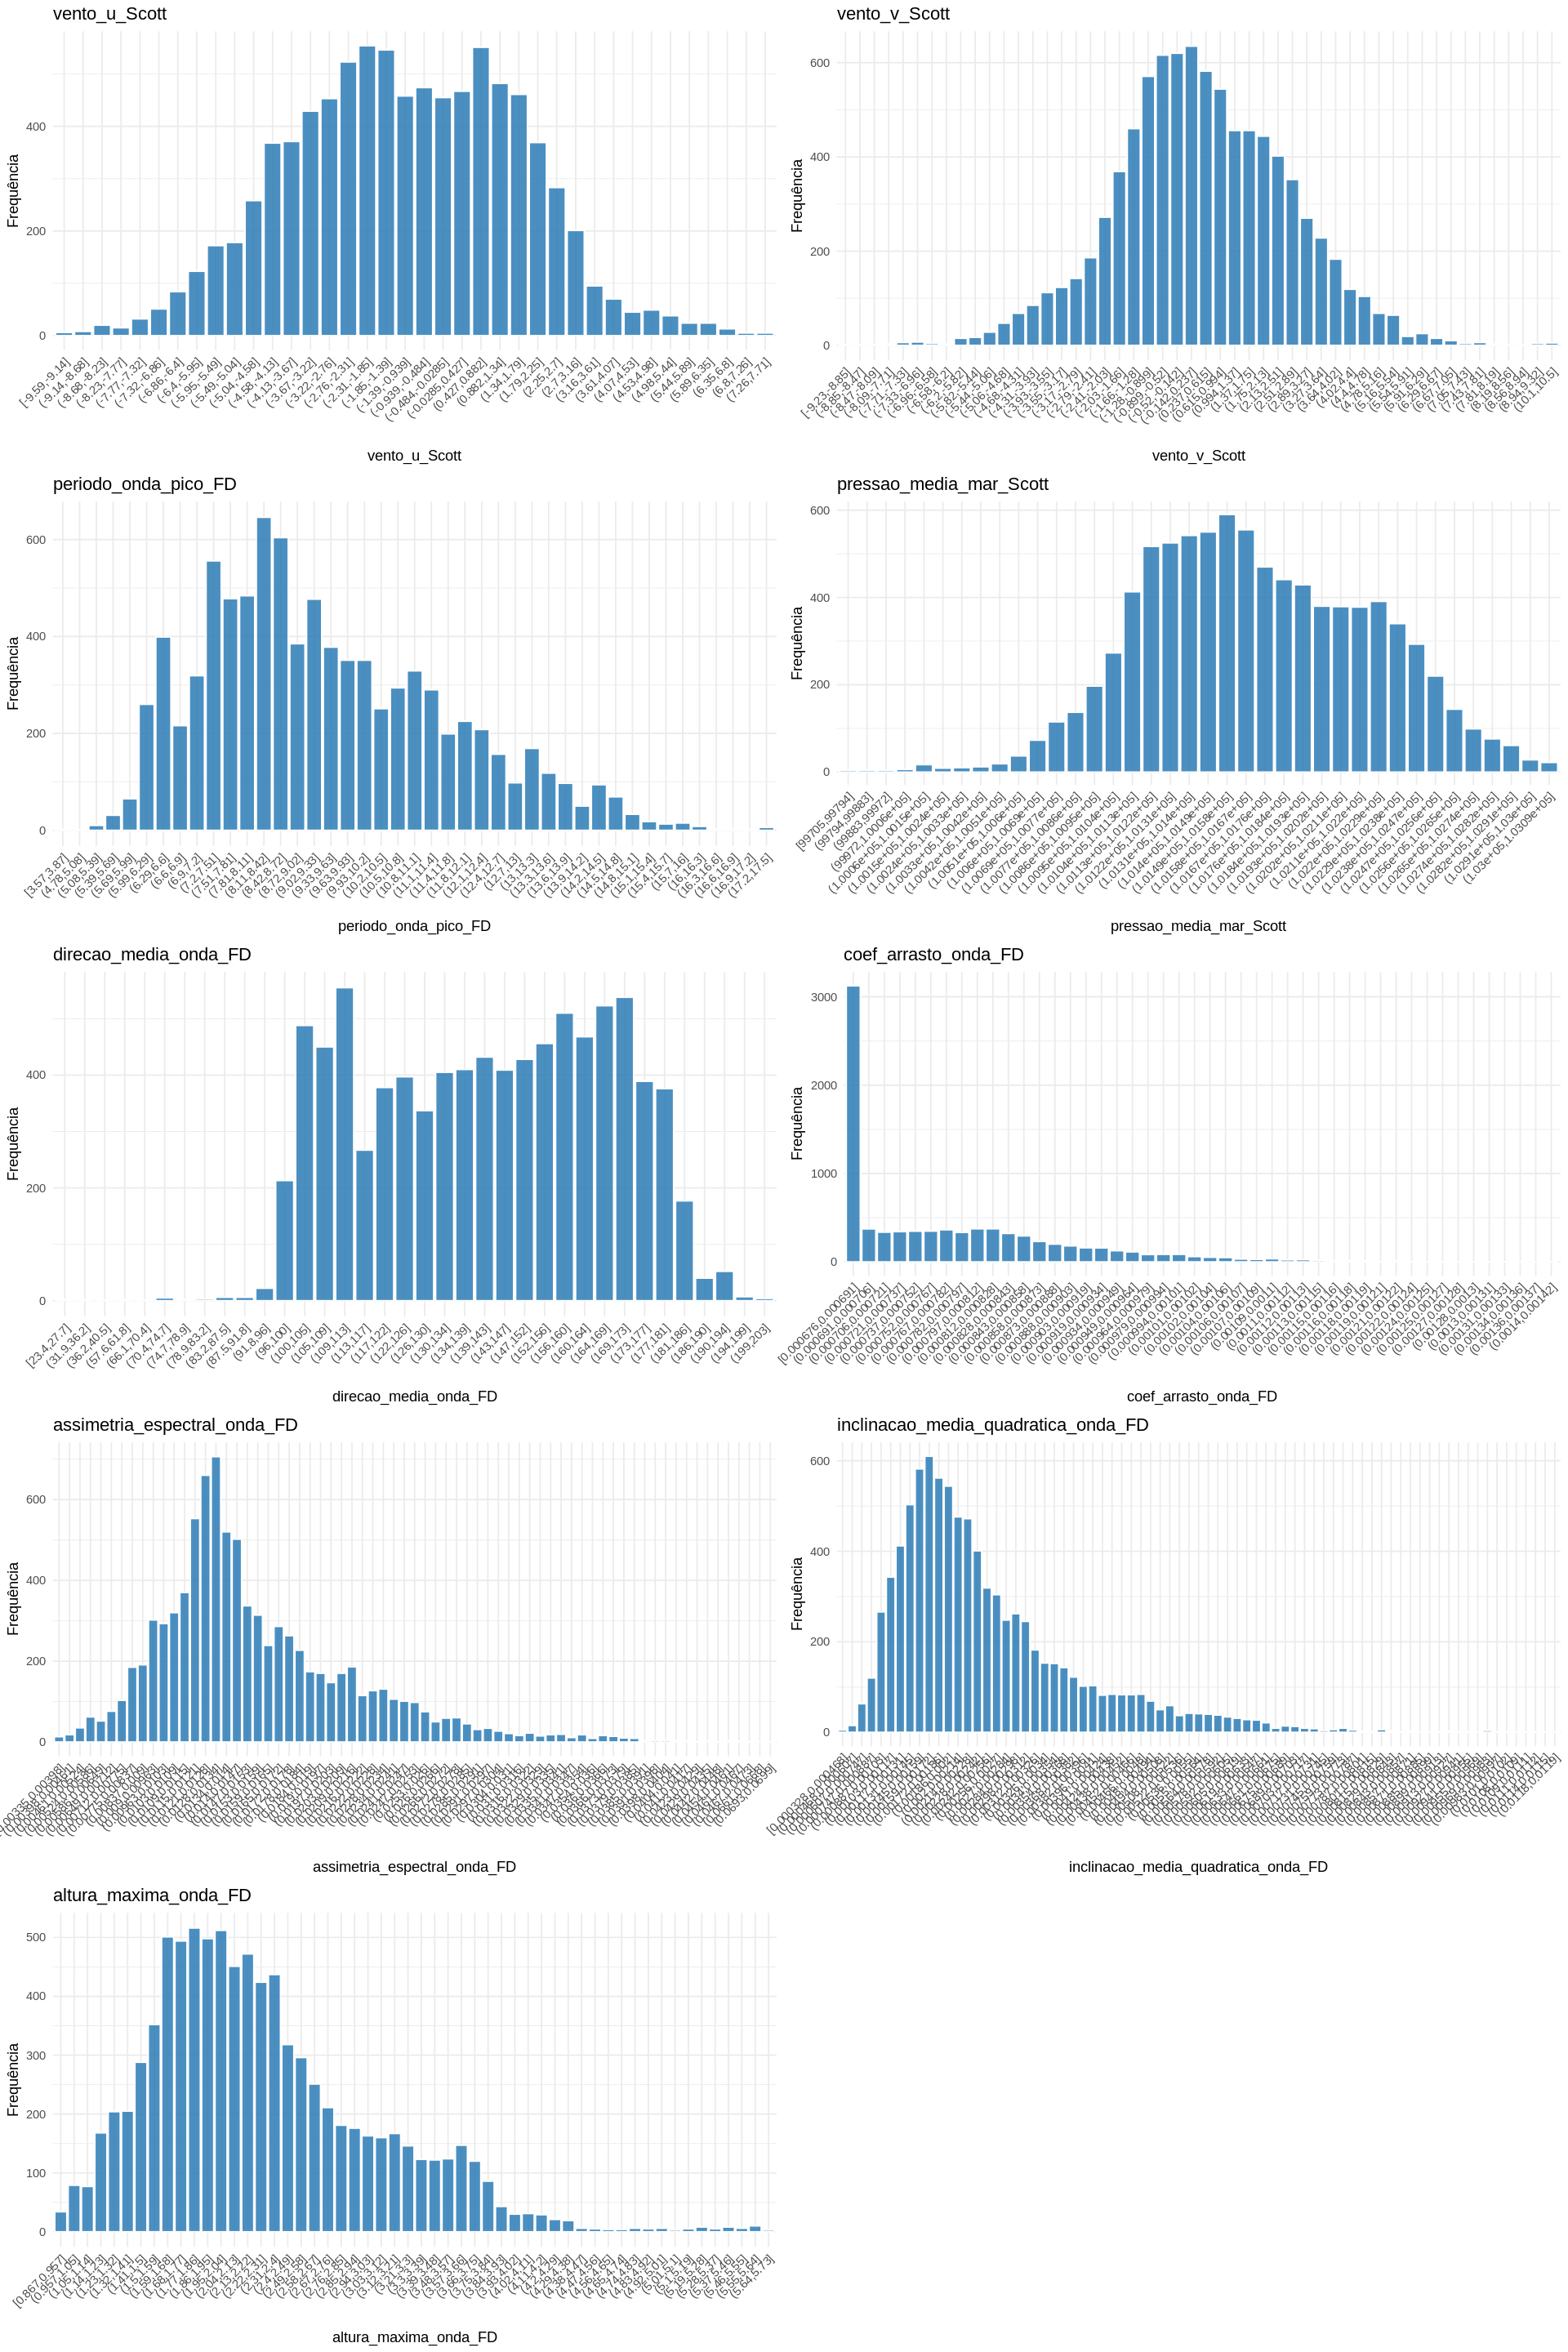

In [40]:
# Gera um gráfico de barras para cada variável qualitativa
options(repr.plot.width = 16, repr.plot.height = 24)
plots_lista <- lapply(vars_quali, function(var) {
  ggplot(df, aes(x = .data[[var]])) +
    geom_bar(fill = "#2C7BB6", color = "white", alpha = 0.85) +
    labs(title = var, x = var, y = "Frequência") +
    theme_minimal(base_size = 11) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
})

do.call(grid.arrange, c(plots_lista, ncol = 2))

# **AJUSTE DE DISTRIBUIÇÕES PARA A VARIÁVEL-ALVO**

In [41]:
install.packages("fitdistrplus")
install.packages("ADGofTest")
library(fitdistrplus) # Fornece fitdist(), gofstat(), denscomp(), qqcomp()
library(ADGofTest)    # Testes de aderência complementares (Anderson-Darling)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [42]:
# ── Ajuste dos modelos ──────────────────────────────────────────────────
# fitdist() estima os parâmetros de cada distribuição por máxima verossimilhança
fit_ln  <- fitdist(y, "lnorm")                        # Log-normal
fit_wb  <- fitdist(y, "weibull")                      # Weibull
fit_gam <- fitdist(y, "gamma")                        # Gamma
fit_chi <- fitdist(y, "chisq", start = list(df = 8759)) # Qui-quadrado (graus de liberdade ≈ n-1)

In [43]:
# ── Resumo dos parâmetros estimados ────────────────────────────────────
summary(fit_ln)
summary(fit_wb)
summary(fit_gam)
summary(fit_chi)

Fitting of the distribution ' lnorm ' by maximum likelihood 
Parameters : 
         estimate  Std. Error
meanlog 0.7665761 0.003444136
sdlog   0.3223534 0.002435266
Loglikelihood:  -9227.854   AIC:  18459.71   BIC:  18473.86 
Correlation matrix:
        meanlog sdlog
meanlog       1     0
sdlog         0     1


Fitting of the distribution ' weibull ' by maximum likelihood 
Parameters : 
      estimate  Std. Error
shape 3.113107 0.023849030
scale 2.531629 0.009219577
Loglikelihood:  -9952.658   AIC:  19909.32   BIC:  19923.47 
Correlation matrix:
          shape     scale
shape 1.0000000 0.3344038
scale 0.3344038 1.0000000


Fitting of the distribution ' gamma ' by maximum likelihood 
Parameters : 
      estimate Std. Error
shape 9.730699 0.14457985
rate  4.290526 0.06542103
Loglikelihood:  -9329.209   AIC:  18662.42   BIC:  18676.57 
Correlation matrix:
         shape     rate
shape 1.000000 0.974444
rate  0.974444 1.000000


Fitting of the distribution ' chisq ' by maximum likelihood 
Parameters : 
   estimate Std. Error
df 3.080433 0.02249244
Loglikelihood:  -14619.07   AIC:  29240.14   BIC:  29247.22 

In [44]:
# ── Estatísticas de aderência (goodness-of-fit) ────────────────────────
# gofstat() calcula AIC, BIC, Kolmogorov-Smirnov e outras métricas para comparação
gofstat(list(fit_ln, fit_wb, fit_gam, fit_chi),
        fitnames = c("Log-normal", "Weibull", "Gamma", "Qui-Quadrado"))

Goodness-of-fit statistics
                             Log-normal     Weibull       Gamma Qui-Quadrado
Kolmogorov-Smirnov statistic  0.0242465   0.0844745  0.04480194    0.2632326
Cramer-von Mises statistic    1.4320198  20.5963692  5.35569472  243.1022701
Anderson-Darling statistic    9.2005999 125.7653522 29.76717505 1329.6611286

Goodness-of-fit criteria
                               Log-normal  Weibull    Gamma Qui-Quadrado
Akaike's Information Criterion   18459.71 19909.32 18662.42     29240.14
Bayesian Information Criterion   18473.86 19923.47 18676.57     29247.22

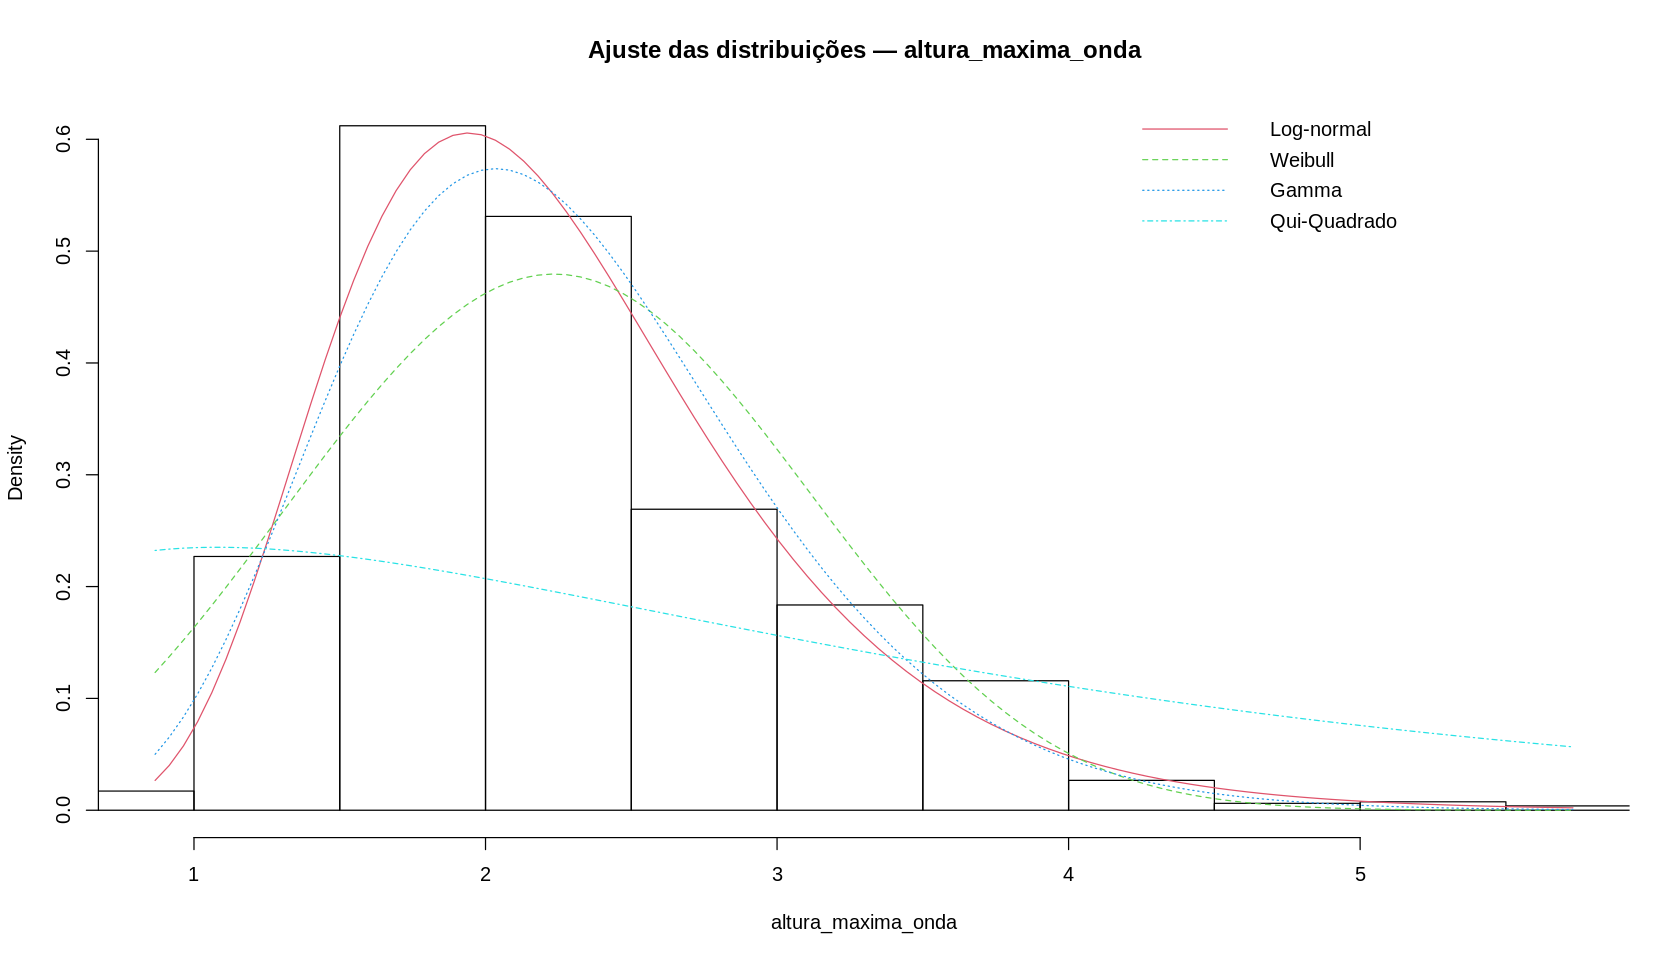

In [45]:
# ── Gráfico comparativo das densidades ajustadas vs. histograma ─────────
options(repr.plot.width = 14, repr.plot.height = 8)
denscomp(list(fit_ln, fit_wb, fit_gam, fit_chi),
         legendtext = c("Log-normal", "Weibull", "Gamma", "Qui-Quadrado"),
         main       = "Ajuste das distribuições — altura_maxima_onda",
         xlab       = "altura_maxima_onda")

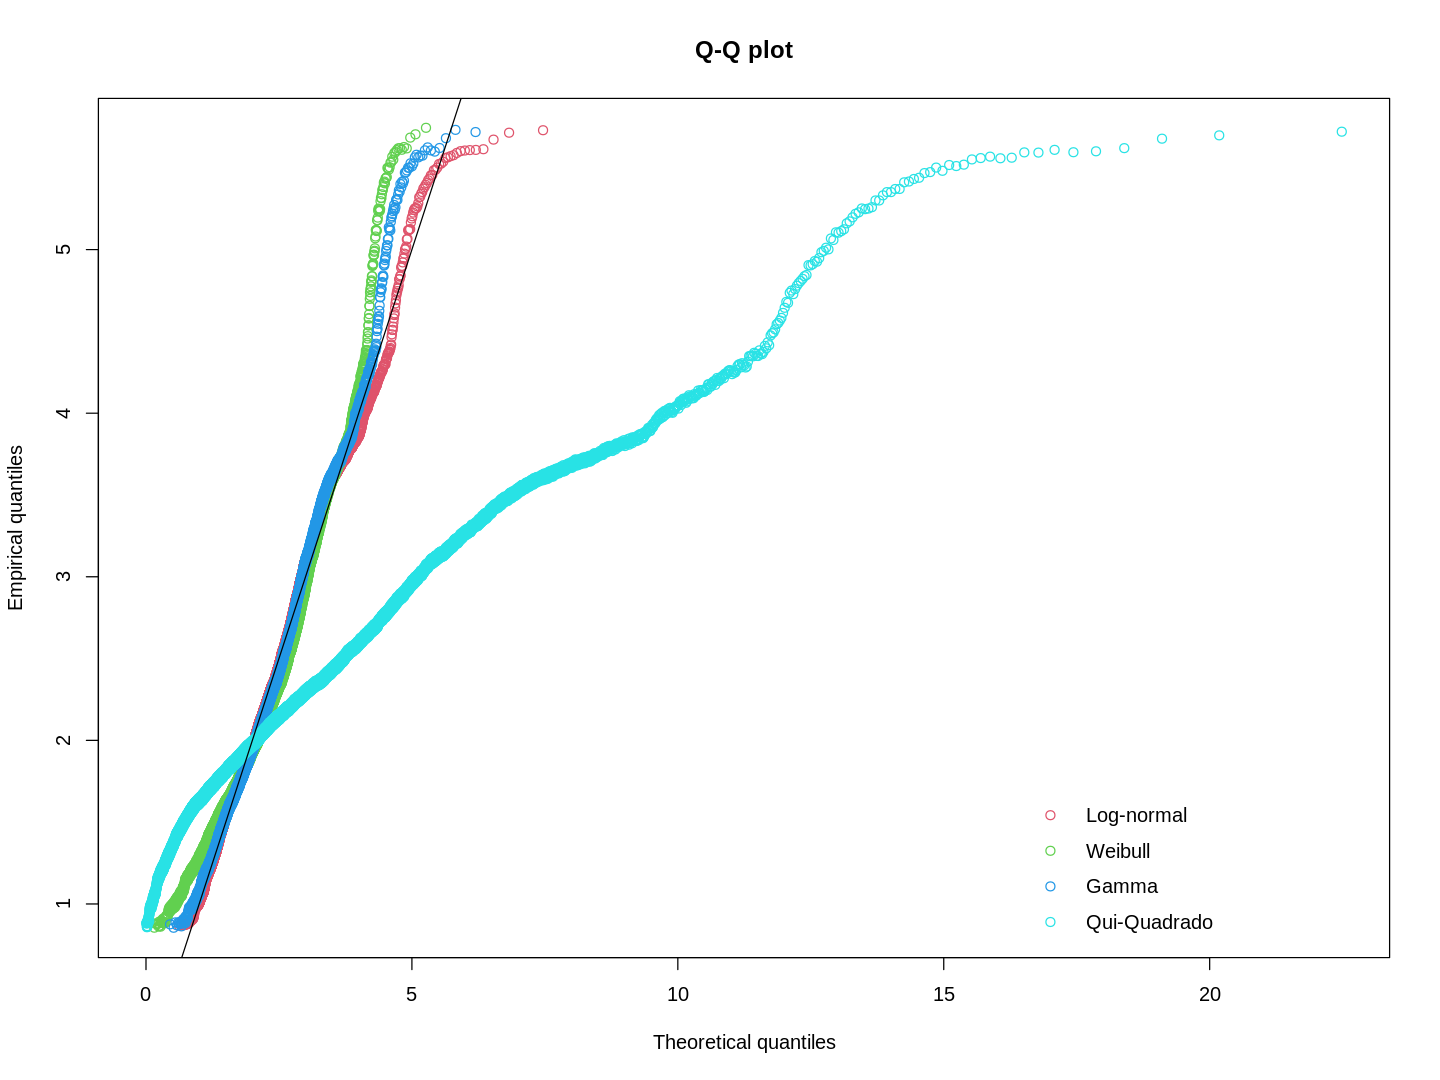

In [46]:
# ── Q-Q plots das distribuições ajustadas ──────────────────────────────
options(repr.plot.width = 12, repr.plot.height = 9)
qqcomp(list(fit_ln, fit_wb, fit_gam, fit_chi),
       legendtext = c("Log-normal", "Weibull", "Gamma", "Qui-Quadrado"))

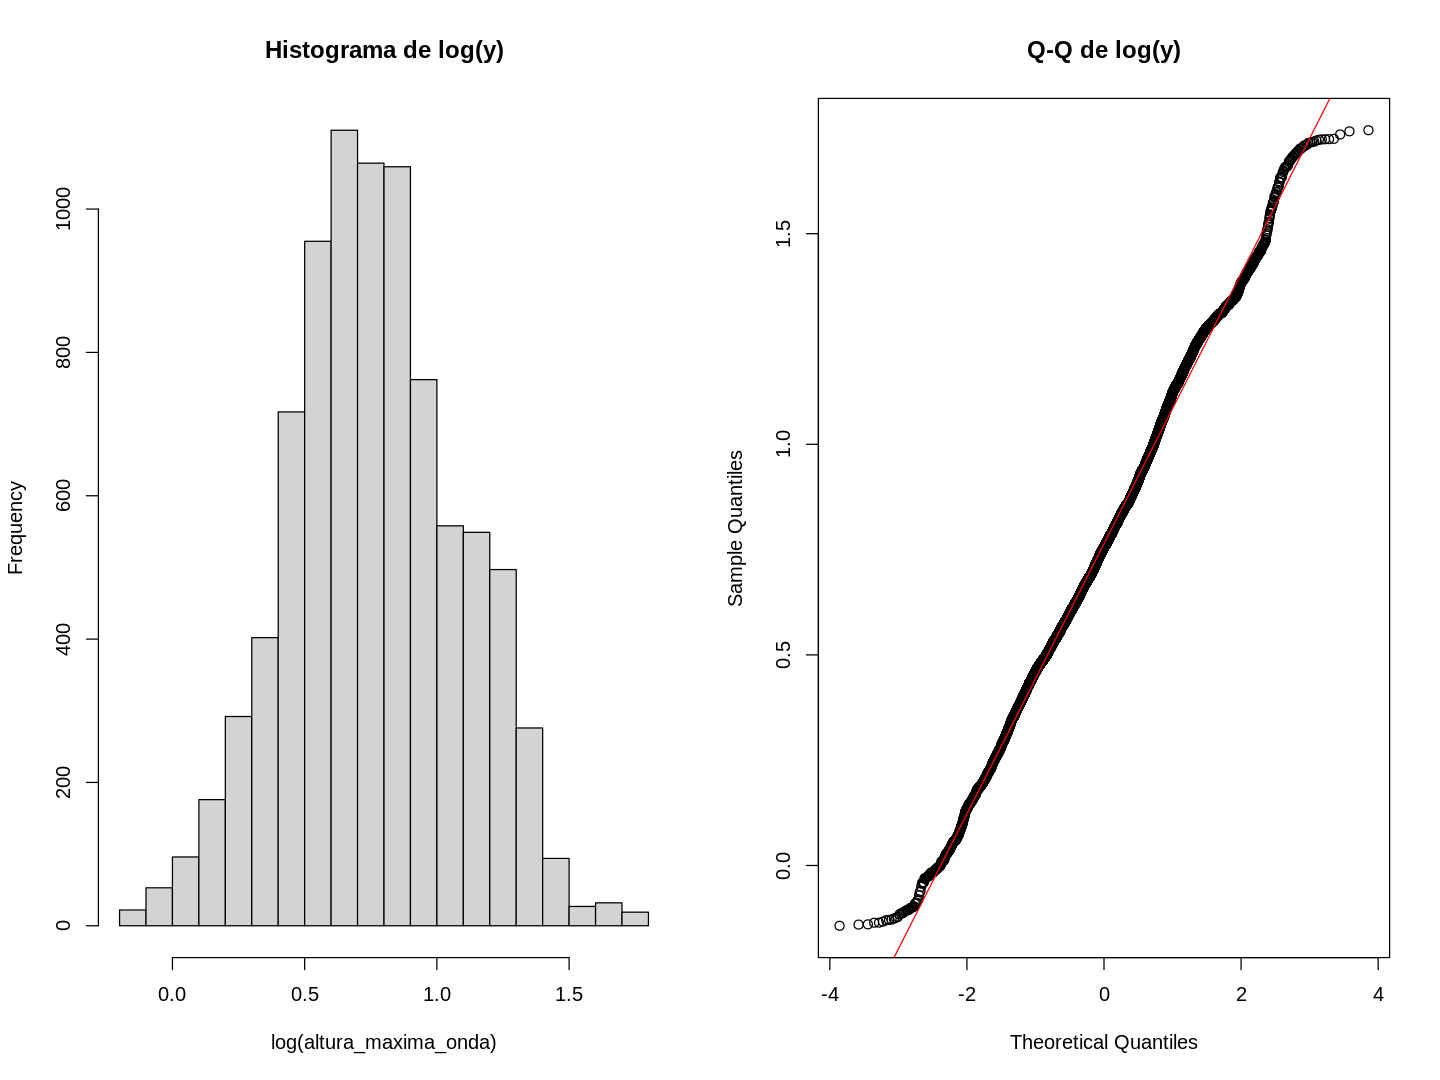

In [47]:
# ── Verificação visual da log-normalidade (log-transformação) ───────────
# Se y ~ Log-normal, então log(y) ~ Normal
# O histograma e Q-Q plot de log(y) devem se assemelhar a uma distribuição normal
options(repr.plot.width = 12, repr.plot.height = 9)
y_log <- log(y)
par(mfrow = c(1, 2))
hist(y_log,  main = "Histograma de log(y)", xlab = "log(altura_maxima_onda)")
qqnorm(y_log, main = "Q-Q de log(y)")
qqline(y_log, col = "red")

# **AJUSTE DE DISTRIBUIÇÕES — SÉRIE SEM OUTLIERS**

In [48]:
# Define os limites inferior e superior da cerca de Tukey (1.5 * IQR)
# Valores fora desse intervalo são considerados outliers pelo critério do boxplot
iqr <- IQR(y)
ls  <- quantile(y, 0.75) + 1.5 * iqr  # limite superior
li  <- quantile(y, 0.25) - 1.5 * iqr  # limite inferior

# Filtra apenas os valores dentro dos limites (sem outliers)
y_sem_outlier <- y[y < ls & y > li]

# Confere o valor máximo após a filtragem e o limite superior calculado
max(y_sem_outlier)
ls

[1] 4.068242

75% 
4.069645

In [49]:
# ── Ajuste dos modelos na série sem outliers ────────────────────────────
fit_ln_2  <- fitdist(y_sem_outlier, "lnorm")
fit_wb_2  <- fitdist(y_sem_outlier, "weibull")
fit_gam_2 <- fitdist(y_sem_outlier, "gamma")
fit_chi_2 <- fitdist(y_sem_outlier, "chisq", start = list(df = 8759))

In [50]:
summary(fit_ln_2)
summary(fit_wb_2)
summary(fit_gam_2)
summary(fit_chi_2)

Fitting of the distribution ' lnorm ' by maximum likelihood 
Parameters : 
         estimate  Std. Error
meanlog 0.7517197 0.003309481
sdlog   0.3067837 0.002340045
Loglikelihood:  -8498.871   AIC:  17001.74   BIC:  17015.86 
Correlation matrix:
        meanlog sdlog
meanlog       1     0
sdlog         0     1


Fitting of the distribution ' weibull ' by maximum likelihood 
Parameters : 
      estimate  Std. Error
shape 3.481744 0.028107146
scale 2.469469 0.008109975
Loglikelihood:  -8888.978   AIC:  17781.96   BIC:  17796.07 
Correlation matrix:
          shape     scale
shape 1.0000000 0.3316208
scale 0.3316208 1.0000000


Fitting of the distribution ' gamma ' by maximum likelihood 
Parameters : 
       estimate Std. Error
shape 10.921237 0.16413315
rate   4.916129 0.07560628
Loglikelihood:  -8511.67   AIC:  17027.34   BIC:  17041.46 
Correlation matrix:
          shape      rate
shape 1.0000000 0.9772144
rate  0.9772144 1.0000000


Fitting of the distribution ' chisq ' by maximum likelihood 
Parameters : 
   estimate Std. Error
df 3.047744 0.02255015
Loglikelihood:  -14209.24   AIC:  28420.48   BIC:  28427.54 

In [51]:
# ── Estatísticas de aderência ──────────────────────────────────────────
gofstat(list(fit_ln_2, fit_wb_2, fit_gam_2, fit_chi_2),
        fitnames = c("Log-normal", "Weibull", "Gamma", "Qui-Quadrado")) # quanto menor melhor

Goodness-of-fit statistics
                              Log-normal     Weibull       Gamma Qui-Quadrado
Kolmogorov-Smirnov statistic  0.02920082  0.07443993  0.03354282    0.2769853
Cramer-von Mises statistic    0.94835787 15.95948747  3.33065190  254.2544072
Anderson-Darling statistic   10.56372460 98.32683868 22.99118565 1382.0262376

Goodness-of-fit criteria
                               Log-normal  Weibull    Gamma Qui-Quadrado
Akaike's Information Criterion   17001.74 17781.96 17027.34     28420.48
Bayesian Information Criterion   17015.86 17796.07 17041.46     28427.54

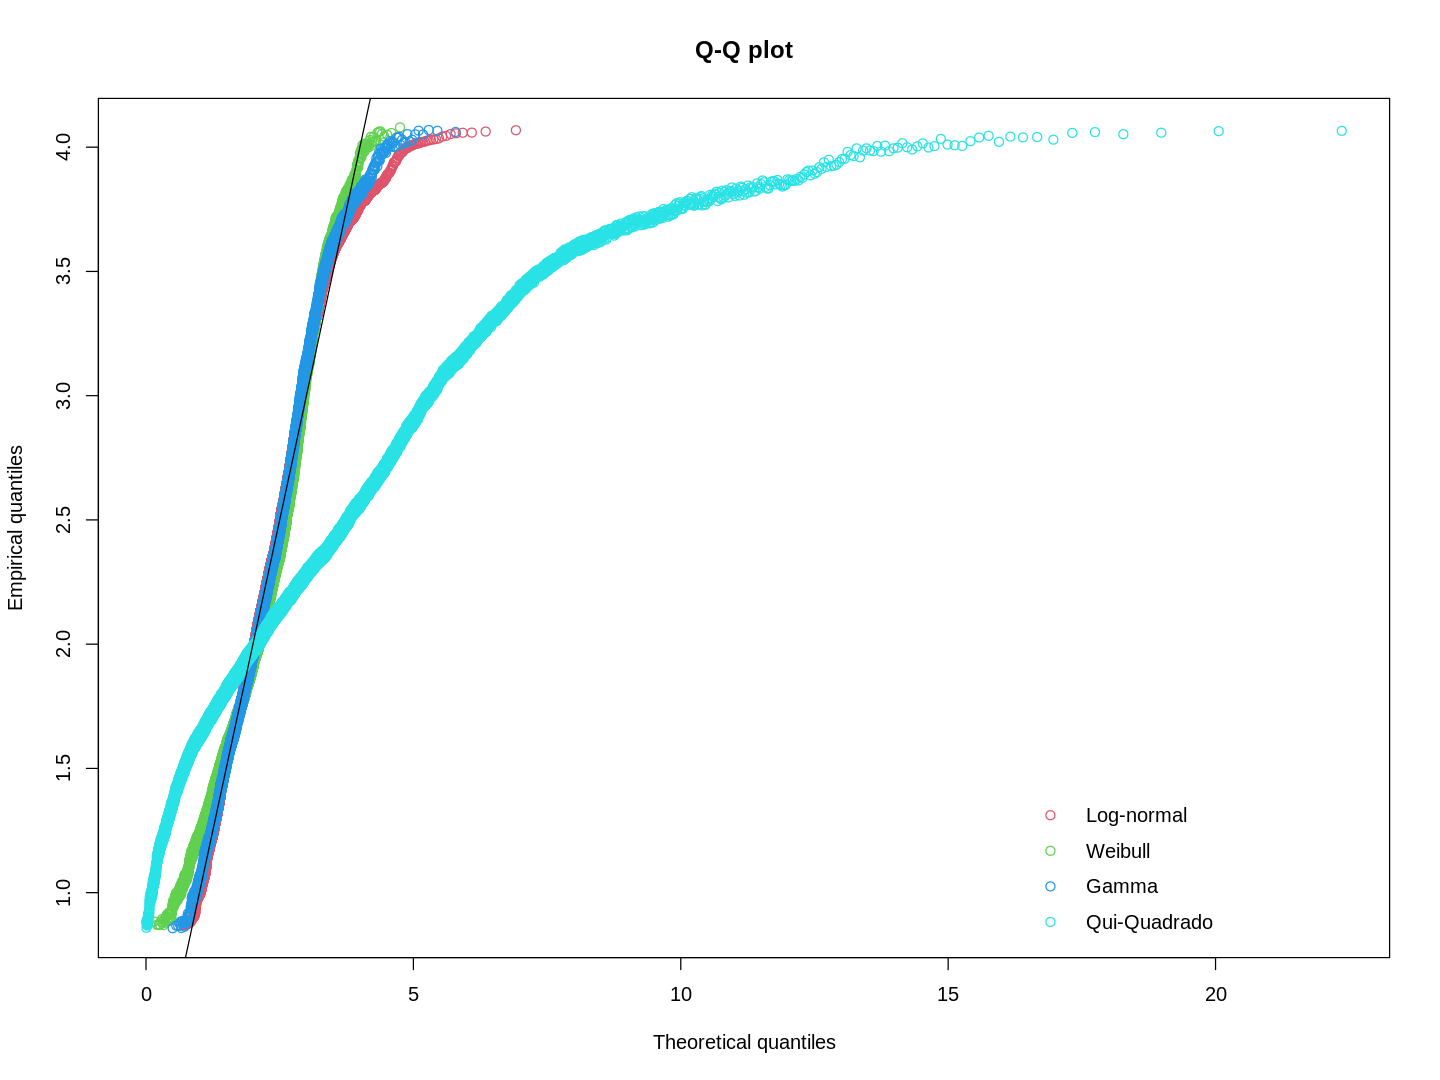

In [52]:
# ── Q-Q plots ──────────────────────────────────────────────────────────
options(repr.plot.width = 12, repr.plot.height = 9)
qqcomp(list(fit_ln_2, fit_wb_2, fit_gam_2, fit_chi_2),
       legendtext = c("Log-normal", "Weibull", "Gamma", "Qui-Quadrado"))

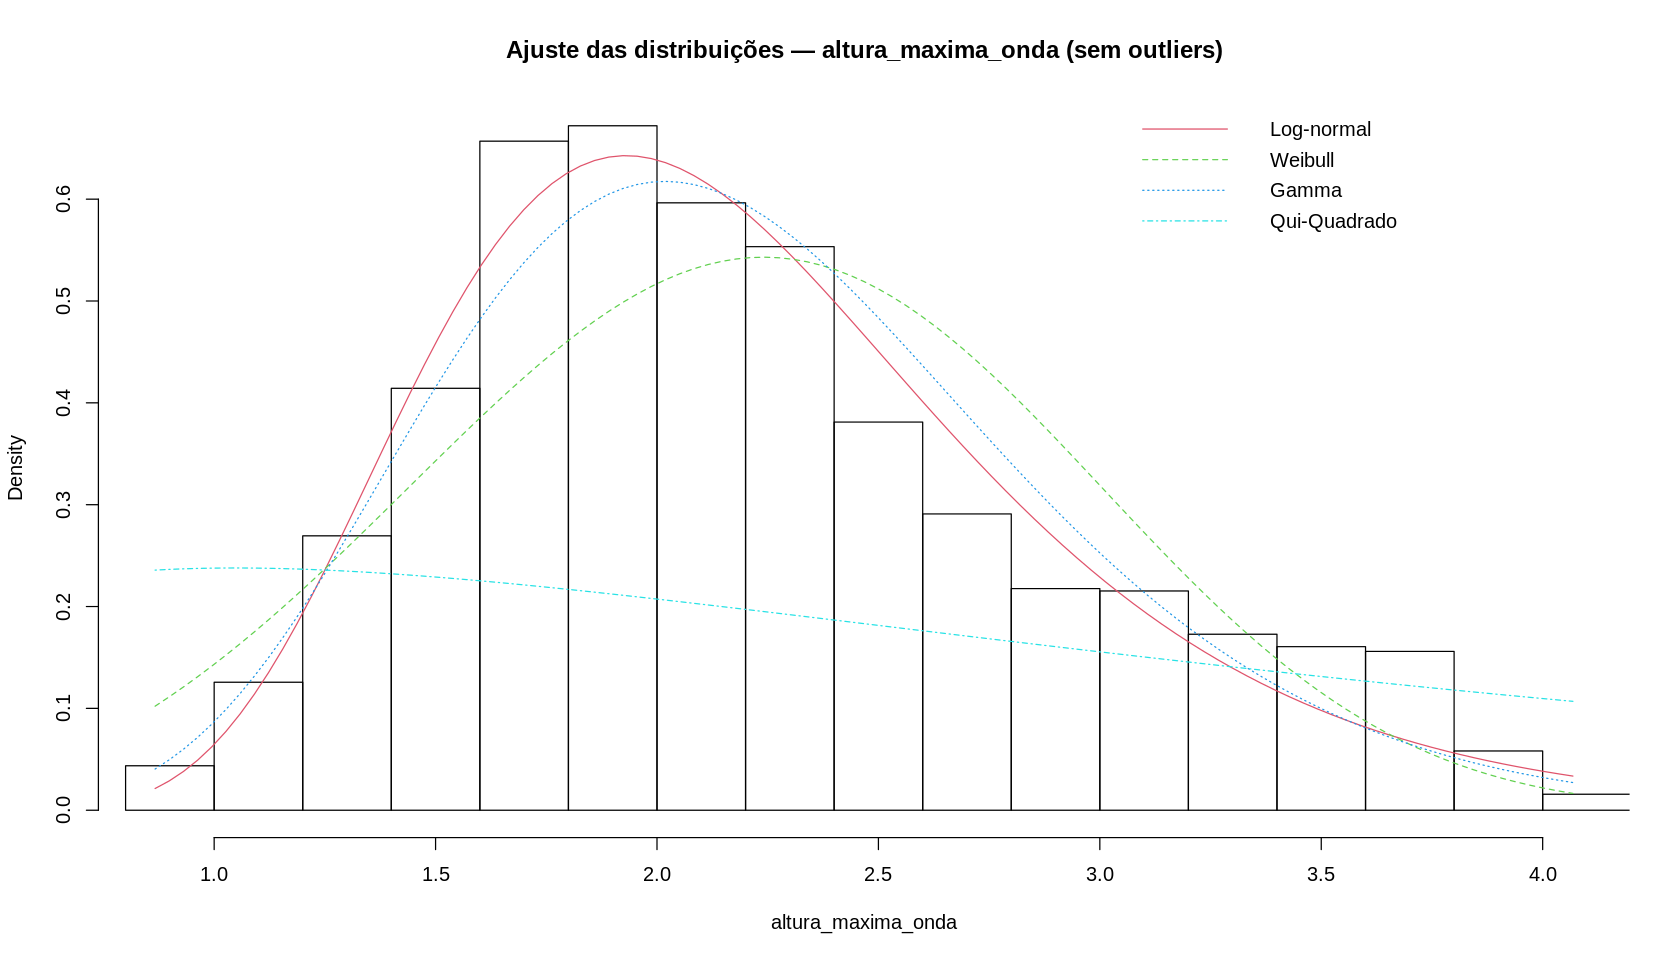

In [53]:
# ── Gráfico comparativo das densidades ─────────────────────────────────
options(repr.plot.width = 14, repr.plot.height = 8)
denscomp(list(fit_ln_2, fit_wb_2, fit_gam_2, fit_chi_2),
         legendtext = c("Log-normal", "Weibull", "Gamma", "Qui-Quadrado"),
         main       = "Ajuste das distribuições — altura_maxima_onda (sem outliers)",
         xlab       = "altura_maxima_onda")

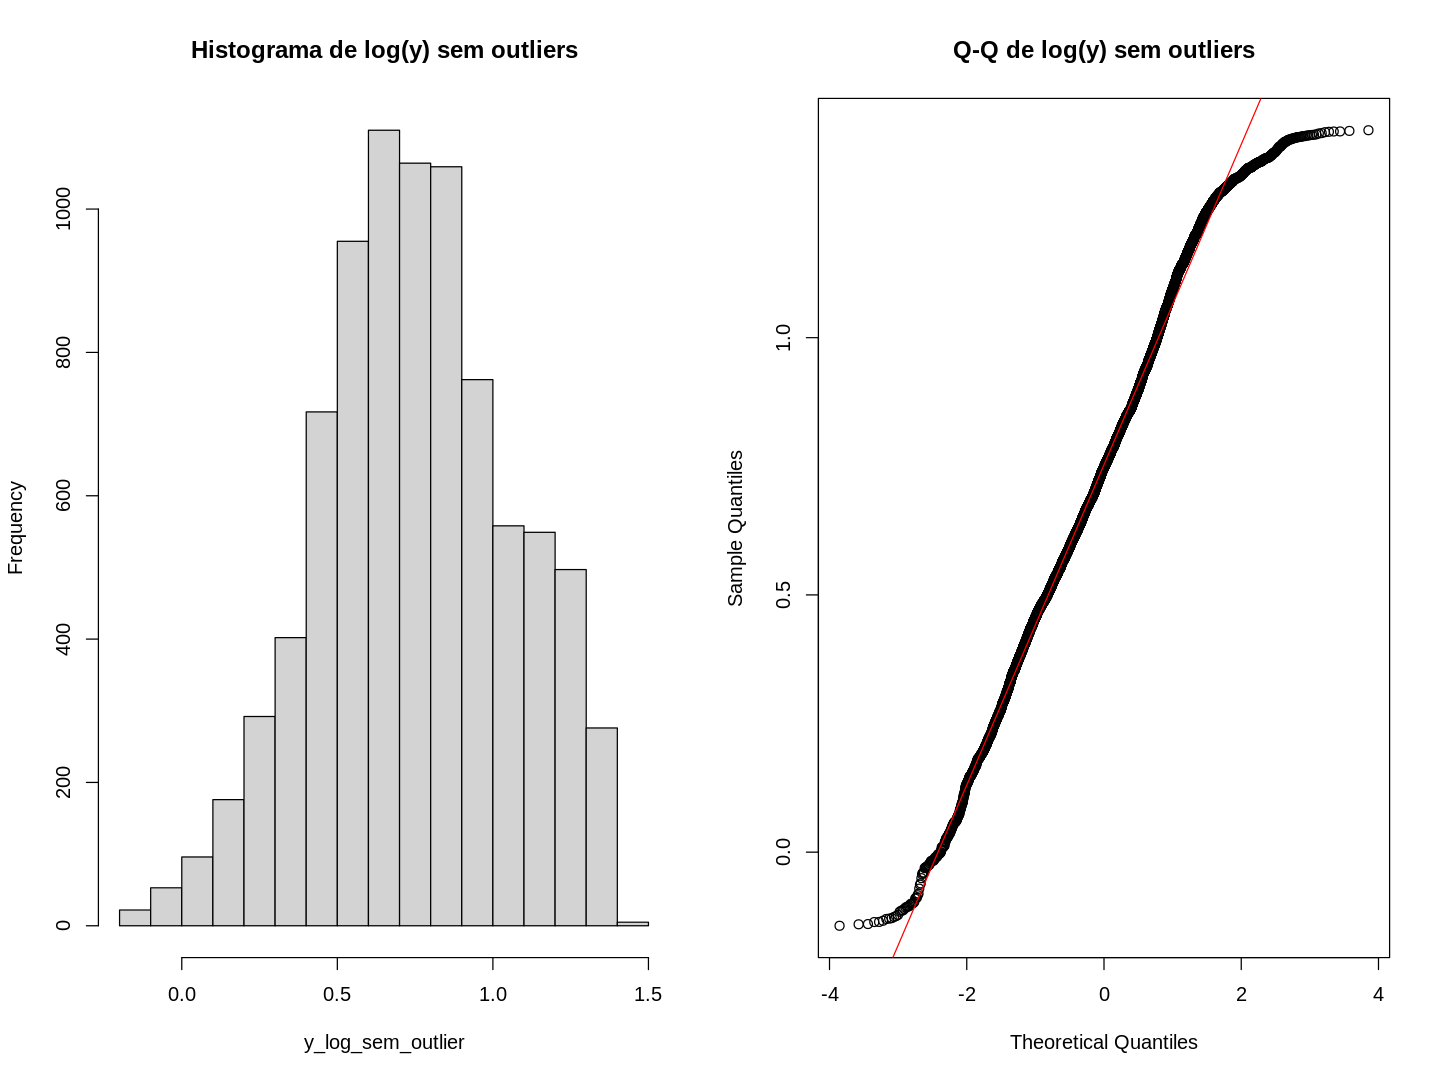

In [54]:
# ── Verificação da log-normalidade na série sem outliers ────────────────
options(repr.plot.width = 12, repr.plot.height = 9)
y_log_sem_outlier <- log(y_sem_outlier)
par(mfrow = c(1, 2))
hist(y_log_sem_outlier,  main = "Histograma de log(y) sem outliers")
qqnorm(y_log_sem_outlier, main = "Q-Q de log(y) sem outliers")
qqline(y_log_sem_outlier, col = "red")

# **ANÁLISE DE CORRELAÇÃO ENTRE VARIÁVEIS**

## **Teste de Correlação de Pearson (variáveis quantitativas)**

In [58]:
install.packages("corrplot")
library(corrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



In [55]:
# Matriz de correlação de Pearson para todas as variáveis numéricas
matriz_cor <- cor(df[vars_numericas])
matriz_cor

,vento_u,vento_v,periodo_onda_pico,pressao_media_mar,direcao_media_onda,coef_arrasto_onda,assimetria_espectral_onda,inclinacao_media_quadratica_onda,altura_maxima_onda
vento_u,1.00000000,-0.01998323,-0.01291393,-0.1724120,0.06961877,-0.30767905,-0.1316704,-0.33128291,-0.1694748
vento_v,-0.01998323,1.00000000,0.03600320,0.1565128,0.38316910,0.35221247,0.1390819,0.23168314,0.2051988
periodo_onda_pico,-0.01291393,0.03600320,1.00000000,0.1665860,0.46895303,-0.00402396,-0.5954810,0.07862776,0.4899329
pressao_media_mar,-0.17241198,0.15651281,0.16658601,1.0000000,0.28719370,0.12195982,0.1733859,0.28022894,0.4357860
direcao_media_onda,0.06961877,0.38316910,0.46895303,0.2871937,1.00000000,0.02481785,-0.1162240,0.12751989,0.4261763
coef_arrasto_onda,-0.30767905,0.35221247,-0.00402396,0.1219598,0.02481785,1.00000000,0.3198059,0.78302137,0.3432223
assimetria_espectral_onda,-0.13167040,0.13908194,-0.59548098,0.1733859,-0.11622402,0.31980588,1.0000000,0.51173771,0.3157004
inclinacao_media_quadratica_onda,-0.33128291,0.23168314,0.07862776,0.2802289,0.12751989,0.78302137,0.5117377,1.00000000,0.6410221
altura_maxima_onda,-0.16947476,0.20519884,0.48993295,0.4357860,0.42617629,0.34322230,0.3157004,0.64102206,1.0000000


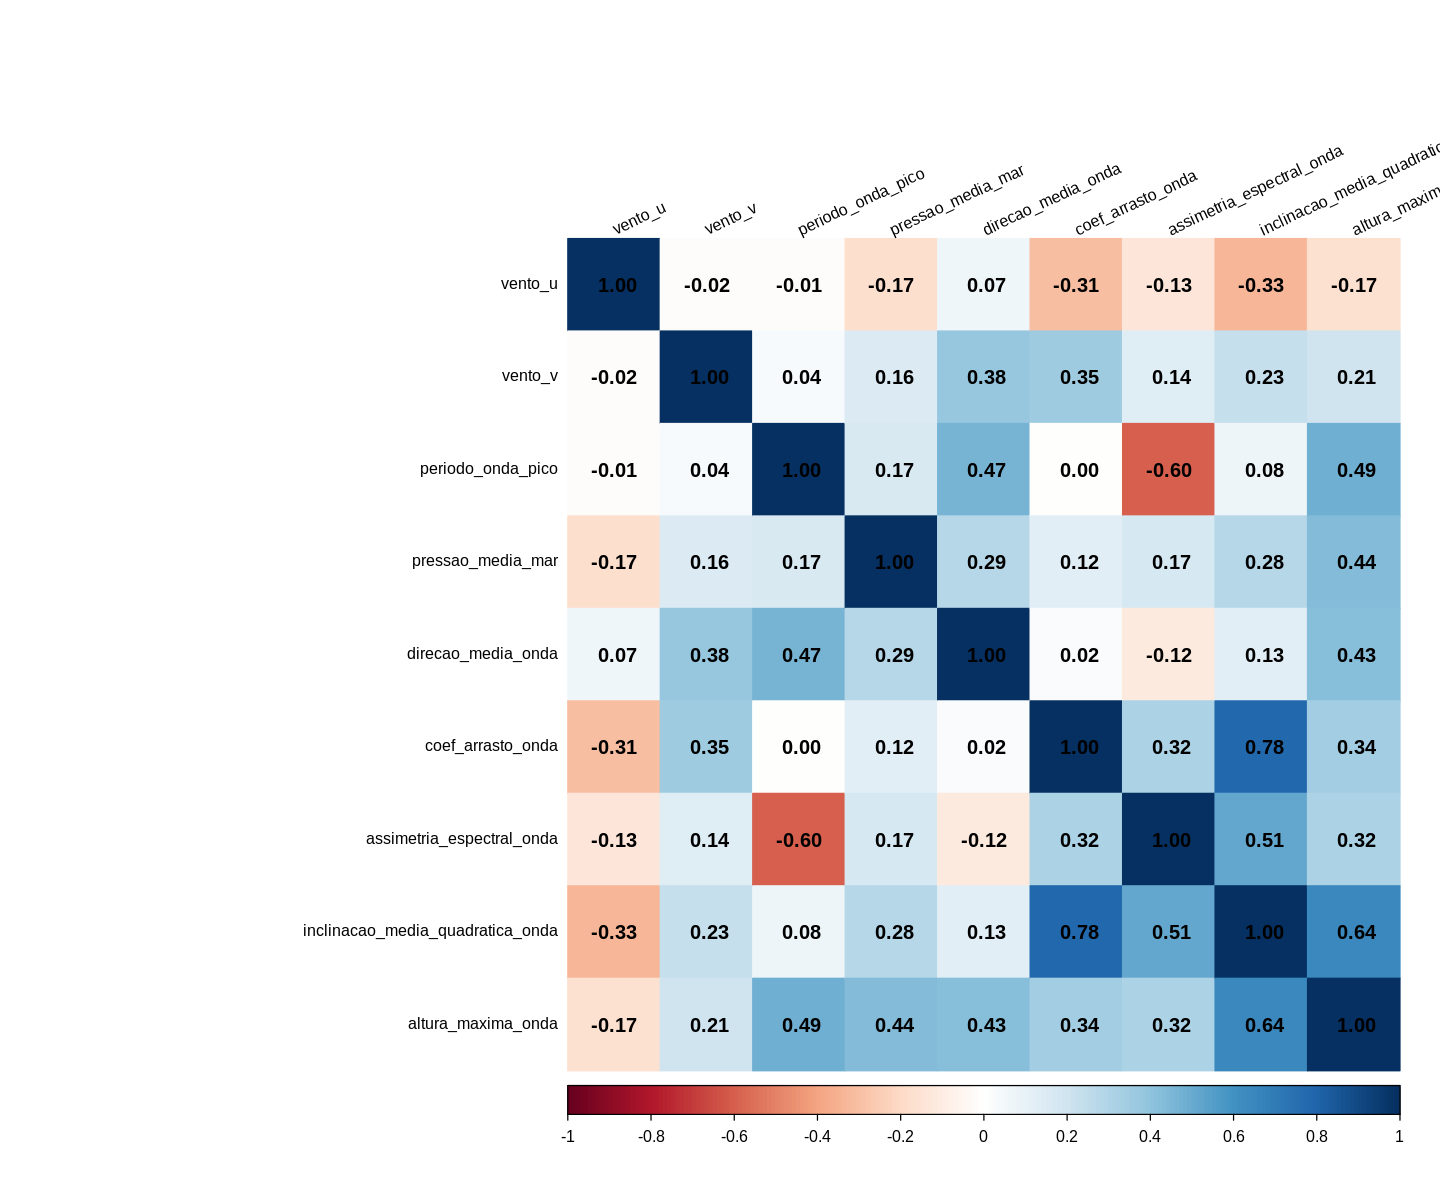

In [59]:
# Heatmap para matriz de correlação
options(repr.plot.width = 12, repr.plot.height = 10)
corrplot(matriz_cor,
         method      = "color",
         addCoef.col = "black",
         number.cex  = 1.0,
         tl.col      = "black",
         tl.srt      = 25,
         tl.cex      = 0.8,
         cl.pos      = "b",
         diag        = TRUE)

In [60]:
# Testa H0: correlação = 0 (independência linear)
# Um p-valor < 0.05 indica correlação estatisticamente significativa
cor.test(df$altura_maxima_onda, df$inclinacao_media_quadratica_onda)


	Pearson's product-moment correlation

data:  df$altura_maxima_onda and df$inclinacao_media_quadratica_onda
t = 78.16, df = 8758, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.6285178 0.6531951
sample estimates:
      cor 
0.6410221 


## **Teste Qui-Quadrado de Independência (variáveis qualitativas)**

In [61]:
#Primeira tentativa: intervalos gerados pelos métodos Scott/FD
tab <- table(df$altura_maxima_onda_FD, df$inclinacao_media_quadratica_onda_FD)
tab
chisq.test(tab)

               
                [0.000328,0.000468] (0.000468,0.000607] (0.000607,0.000747]
  [0.867,0.957]                   0                   4                  13
  (0.957,1.05]                    5                   2                   0
  (1.05,1.14]                     0                   4                   4
  (1.14,1.23]                     0                   0                  19
  (1.23,1.32]                     0                   0                  11
  (1.32,1.41]                     0                   0                   0
  (1.41,1.5]                      0                   5                  10
  (1.5,1.59]                      0                   0                   1
  (1.59,1.68]                     0                   0                   0
  (1.68,1.77]                     0                   0                   1
  (1.77,1.86]                     0                   0                   0
  (1.86,1.95]                     0                   0                 

Warning message in chisq.test(tab):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  tab
X-squared = NaN, df = 4346, p-value = NA


In [ ]:
# Segunda tentativa: apenas 3 intervalos por variável
# Reduzir o número de classes garante frequências suficientes em cada célula,
# atendendo aos pressupostos do teste qui-quadrado

In [62]:
# Divide altura_maxima_onda em 3 intervalos iguais
bks1 <- seq(min(df$altura_maxima_onda), max(df$altura_maxima_onda), length.out = 3)
var1 <- cut(df$altura_maxima_onda, bks1)

# Divide inclinacao_media_quadratica_onda em 3 intervalos iguais
bks2 <- seq(min(df$inclinacao_media_quadratica_onda),
            max(df$inclinacao_media_quadratica_onda),
            length.out = 3)
var2 <- cut(df$inclinacao_media_quadratica_onda, bks2)

In [63]:
# Tabela de contingência cruzada com 3×3 = 9 células
tab_menos_intervalos <- table(var1, var2)
tab_menos_intervalos

             var2
var1          (0.000328,0.00612] (0.00612,0.0119]
  (0.867,3.3]               7701               78
  (3.3,5.73]                 843              136

In [64]:
# Teste qui-quadrado com frequências adequadas
# H0: as variáveis são independentes
# p-valor < 0.05 → rejeita H0 → as variáveis são dependentes
chisq.test(tab_menos_intervalos)


	Pearson's Chi-squared test with Yates' continuity correction

data:  tab_menos_intervalos
X-squared = 600.61, df = 1, p-value < 2.2e-16


## **Boxplot comparativo (quantitativa vs. qualitativa)**

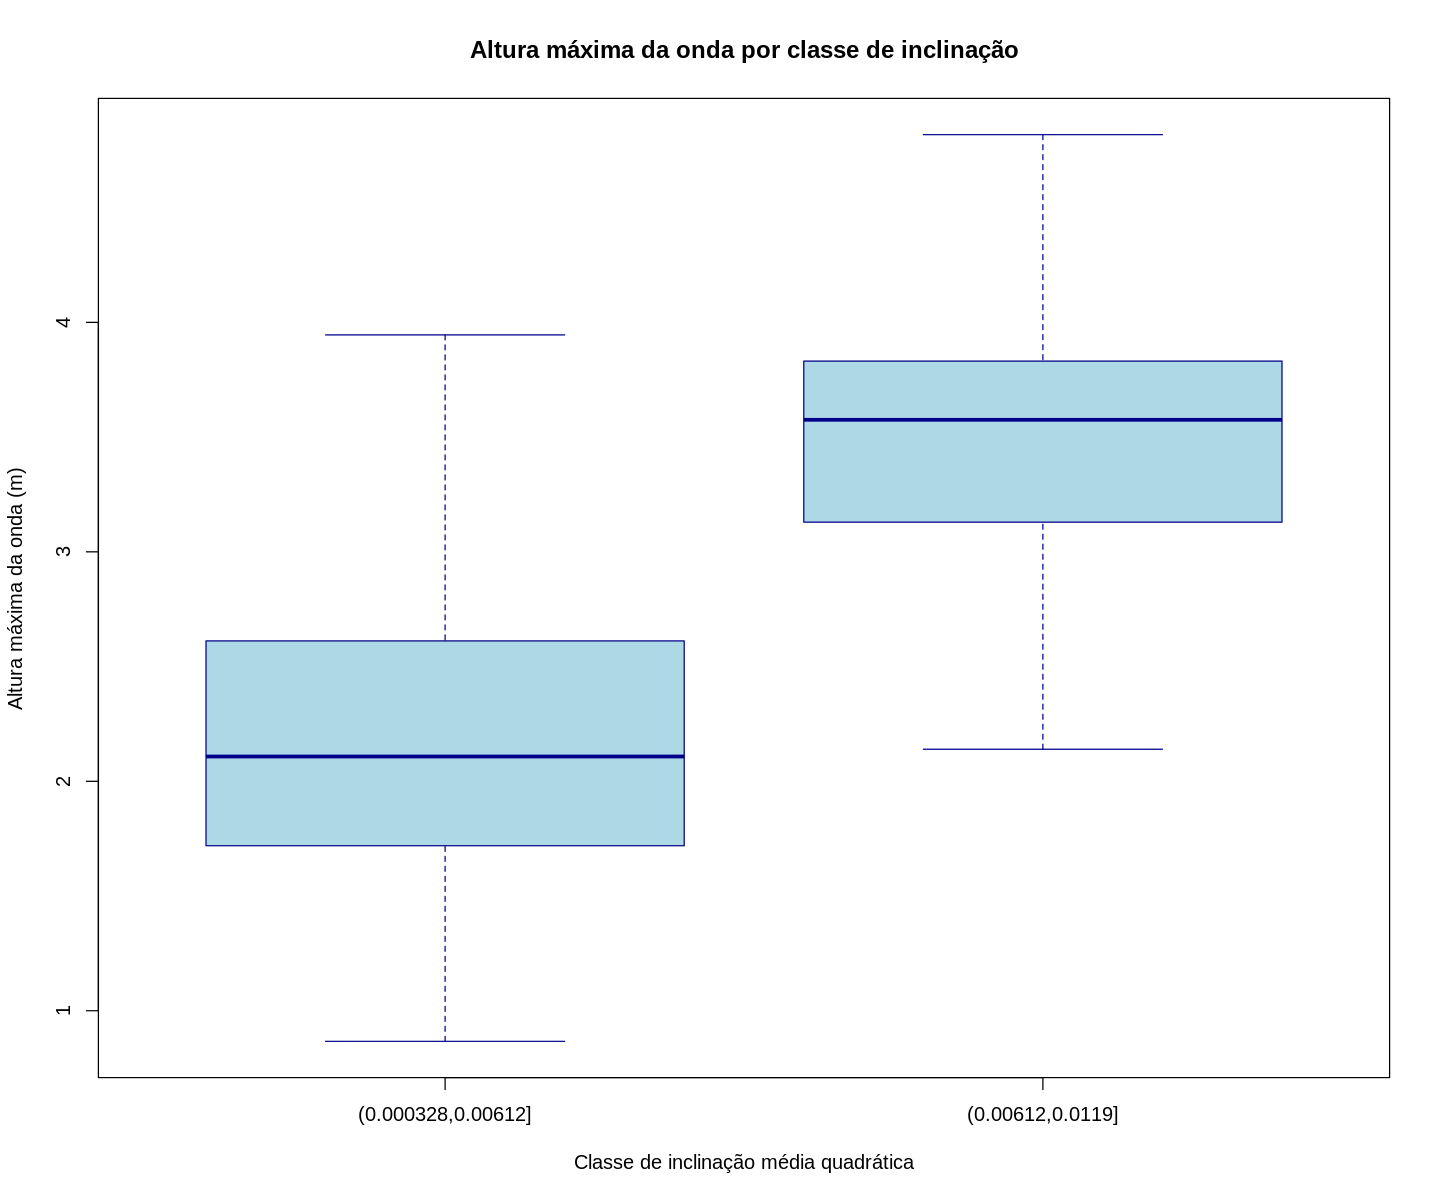

In [65]:
boxplot(df$altura_maxima_onda ~ var2,
        data    = df,
        outline = FALSE,
        main    = "Altura máxima da onda por classe de inclinação",
        xlab    = "Classe de inclinação média quadrática",
        ylab    = "Altura máxima da onda (m)",
        col     = "lightblue",
        border  = "darkblue")